# TCC Parte 4 - Resultados Segundo experimento

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches

from scipy.stats import pearsonr
from scikit_posthocs import posthoc_dunn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import scikit_posthocs as sp

from modules.financial_helpers import *
from modules.dataframe_helpers import get_sharpe_series_from_results, get_metric_distribution_from_results
from modules.chart_helpers import *
from modules.statistical_tests import *

In [2]:
with open("results/lstm_01", "rb") as f:
    results_lstm_1 = pickle.load(f)

with open("results/gru_01", "rb") as f:
    results_gru_1 = pickle.load(f)

with open("results/rf_01", "rb") as f:
    results_rf_1 = pickle.load(f)

with open("results/rg_01", "rb") as f:
    results_rg_1 = pickle.load(f)

with open("results/rnn_01", "rb") as f:
    results_rnn_1 = pickle.load(f)

daily_returns = pd.read_csv("data/buy_and_hold_df.csv")
daily_returns['Date'] = pd.to_datetime(daily_returns['Date'], format='%Y-%m-%d')
daily_returns.set_index('Date', inplace=True)

In [3]:
lstm_sharpes_1 = get_sharpe_series_from_results(results_lstm_1, daily_returns)
gru_sharpes_1 = get_sharpe_series_from_results(results_gru_1, daily_returns)
rf_sharpes_1 = get_sharpe_series_from_results(results_rf_1, daily_returns)
rnn_sharpes_1 = get_sharpe_series_from_results(results_rnn_1, daily_returns)
rg_sharpes_1 = get_sharpe_series_from_results(results_rg_1, daily_returns)

In [4]:
best_results_lstm_01, cuml_perf_lstm_01, max_sharpe_lstm_01, best_exp_idx_lstm = find_best_experiment(results_lstm_1, daily_returns)
best_results_gru_1, cuml_perf_gru_1, max_sharpe_gru_1, best_exp_idx_gru = find_best_experiment(results_gru_1, daily_returns)
best_results_rnn_1, cuml_perf_rnn_1, max_sharpe_rnn_1, best_exp_idx_rnn = find_best_experiment(results_rnn_1, daily_returns)
best_results_rf_1, cuml_perf_rf_1, max_sharpe_rf_1, best_exp_idx_rf = find_best_experiment(results_rf_1, daily_returns)
best_results_rg_1, cuml_perf_rg_1, max_sharpe_rg_1, best_exp_idx_rg = find_best_experiment(results_rg_1, daily_returns)

Selected exp number 13
Selected exp number 23
Selected exp number 22
Selected exp number 13
Selected exp number 24


In [5]:
buy_and_hold_cuml_returns, portfolio_returns = compute_buyandhold_cumulative_returns(daily_returns)
buy_and_hold_sharpe = compute_sharpe_ratio(portfolio_returns)
buy_and_hold_sharpe

0.006135881679665358

## Distribuição de Sharpe Ratios

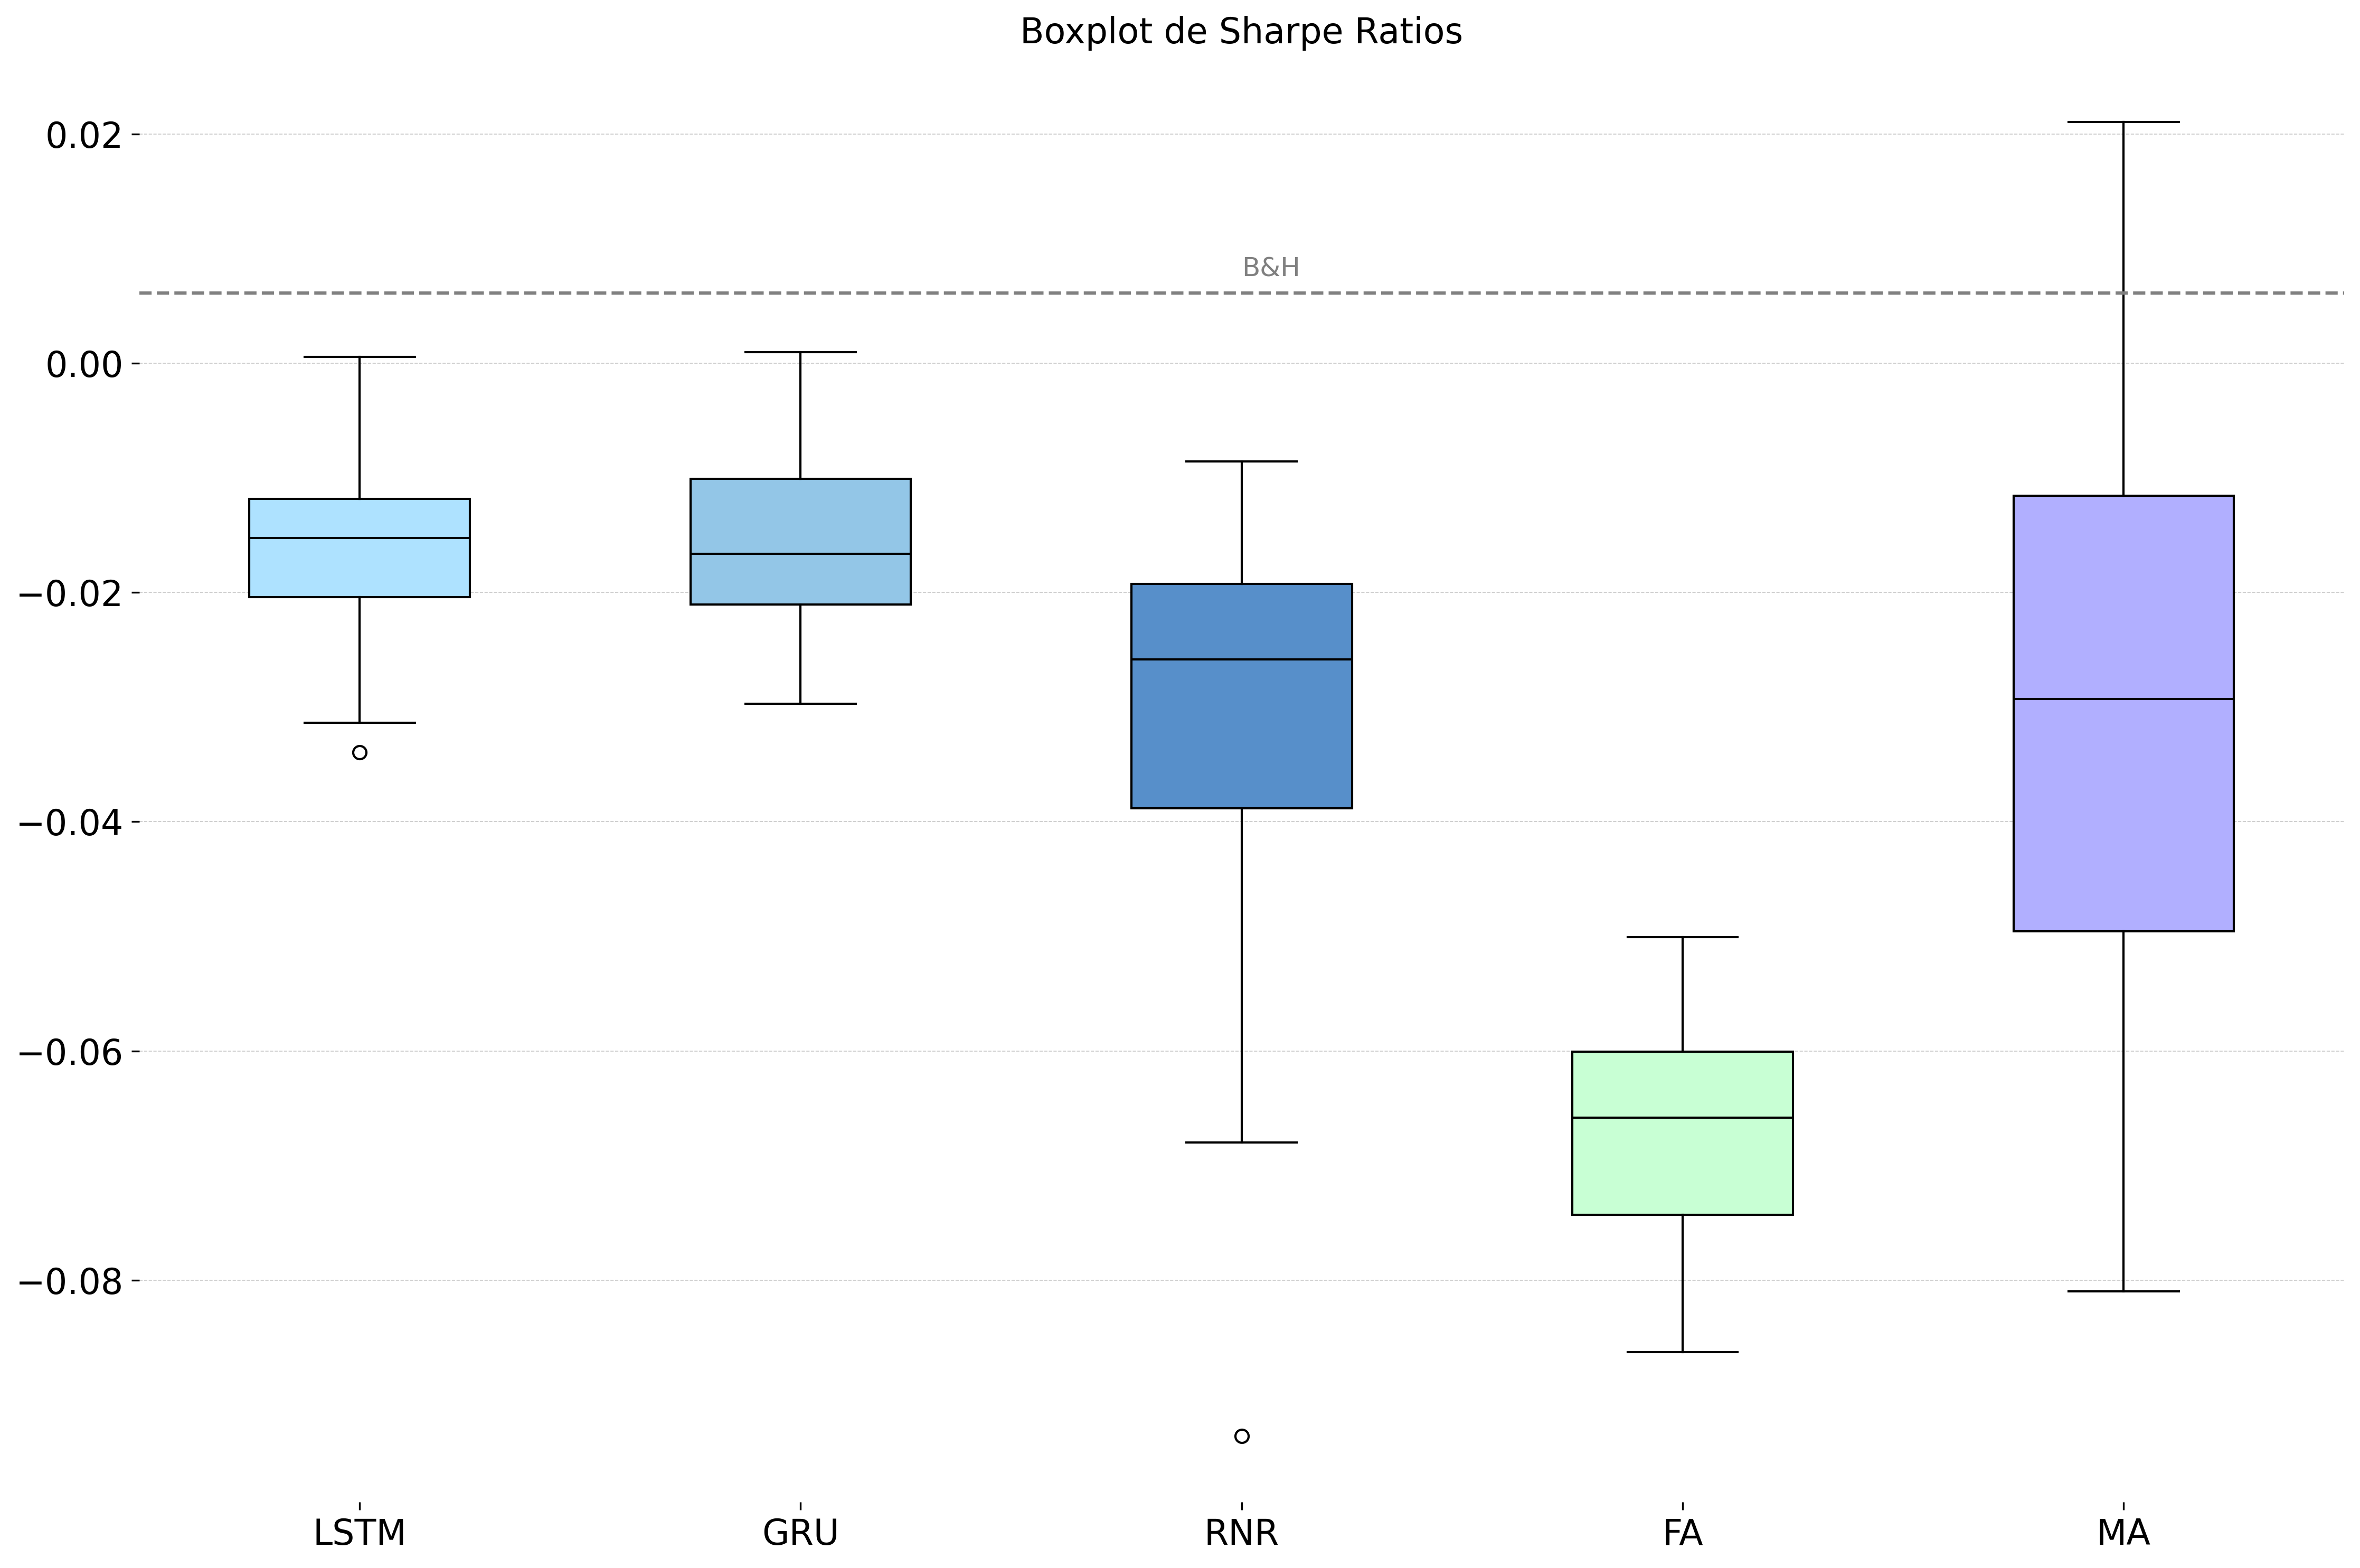

In [6]:
plot_distribution_and_stddev([
    lstm_sharpes_1,
    gru_sharpes_1,
    rnn_sharpes_1,
    rf_sharpes_1,
    rg_sharpes_1
],
"Sharpe Ratios",
legend_loc="lower right",
legend_size=16,
benchmark_value=buy_and_hold_sharpe,
benchmark_color=model_colors["B&H"],
benchmark_name="B&H"
)

In [7]:
print_statistics_table_for_series([
    lstm_sharpes_1,
    gru_sharpes_1,
    rnn_sharpes_1,
    rf_sharpes_1,
    rg_sharpes_1
])

+--------+---------+---------+---------+---------+---------------+--------+
| modelo |  média  | mediana |   max   |   min   | desvio padrão | range  |
+--------+---------+---------+---------+---------+---------------+--------+
|  LSTM  | -0.0162 | -0.0153 |  0.0006 | -0.0340 |     0.0080    | 0.0345 |
|  GRU   | -0.0163 | -0.0166 |  0.0010 | -0.0297 |     0.0075    | 0.0307 |
|  RNR   | -0.0308 | -0.0258 | -0.0086 | -0.0936 |     0.0181    | 0.0850 |
|   FA   | -0.0669 | -0.0658 | -0.0501 | -0.0863 |     0.0102    | 0.0362 |
|   MA   | -0.0304 | -0.0293 |  0.0210 | -0.0810 |     0.0241    | 0.1020 |
+--------+---------+---------+---------+---------+---------------+--------+


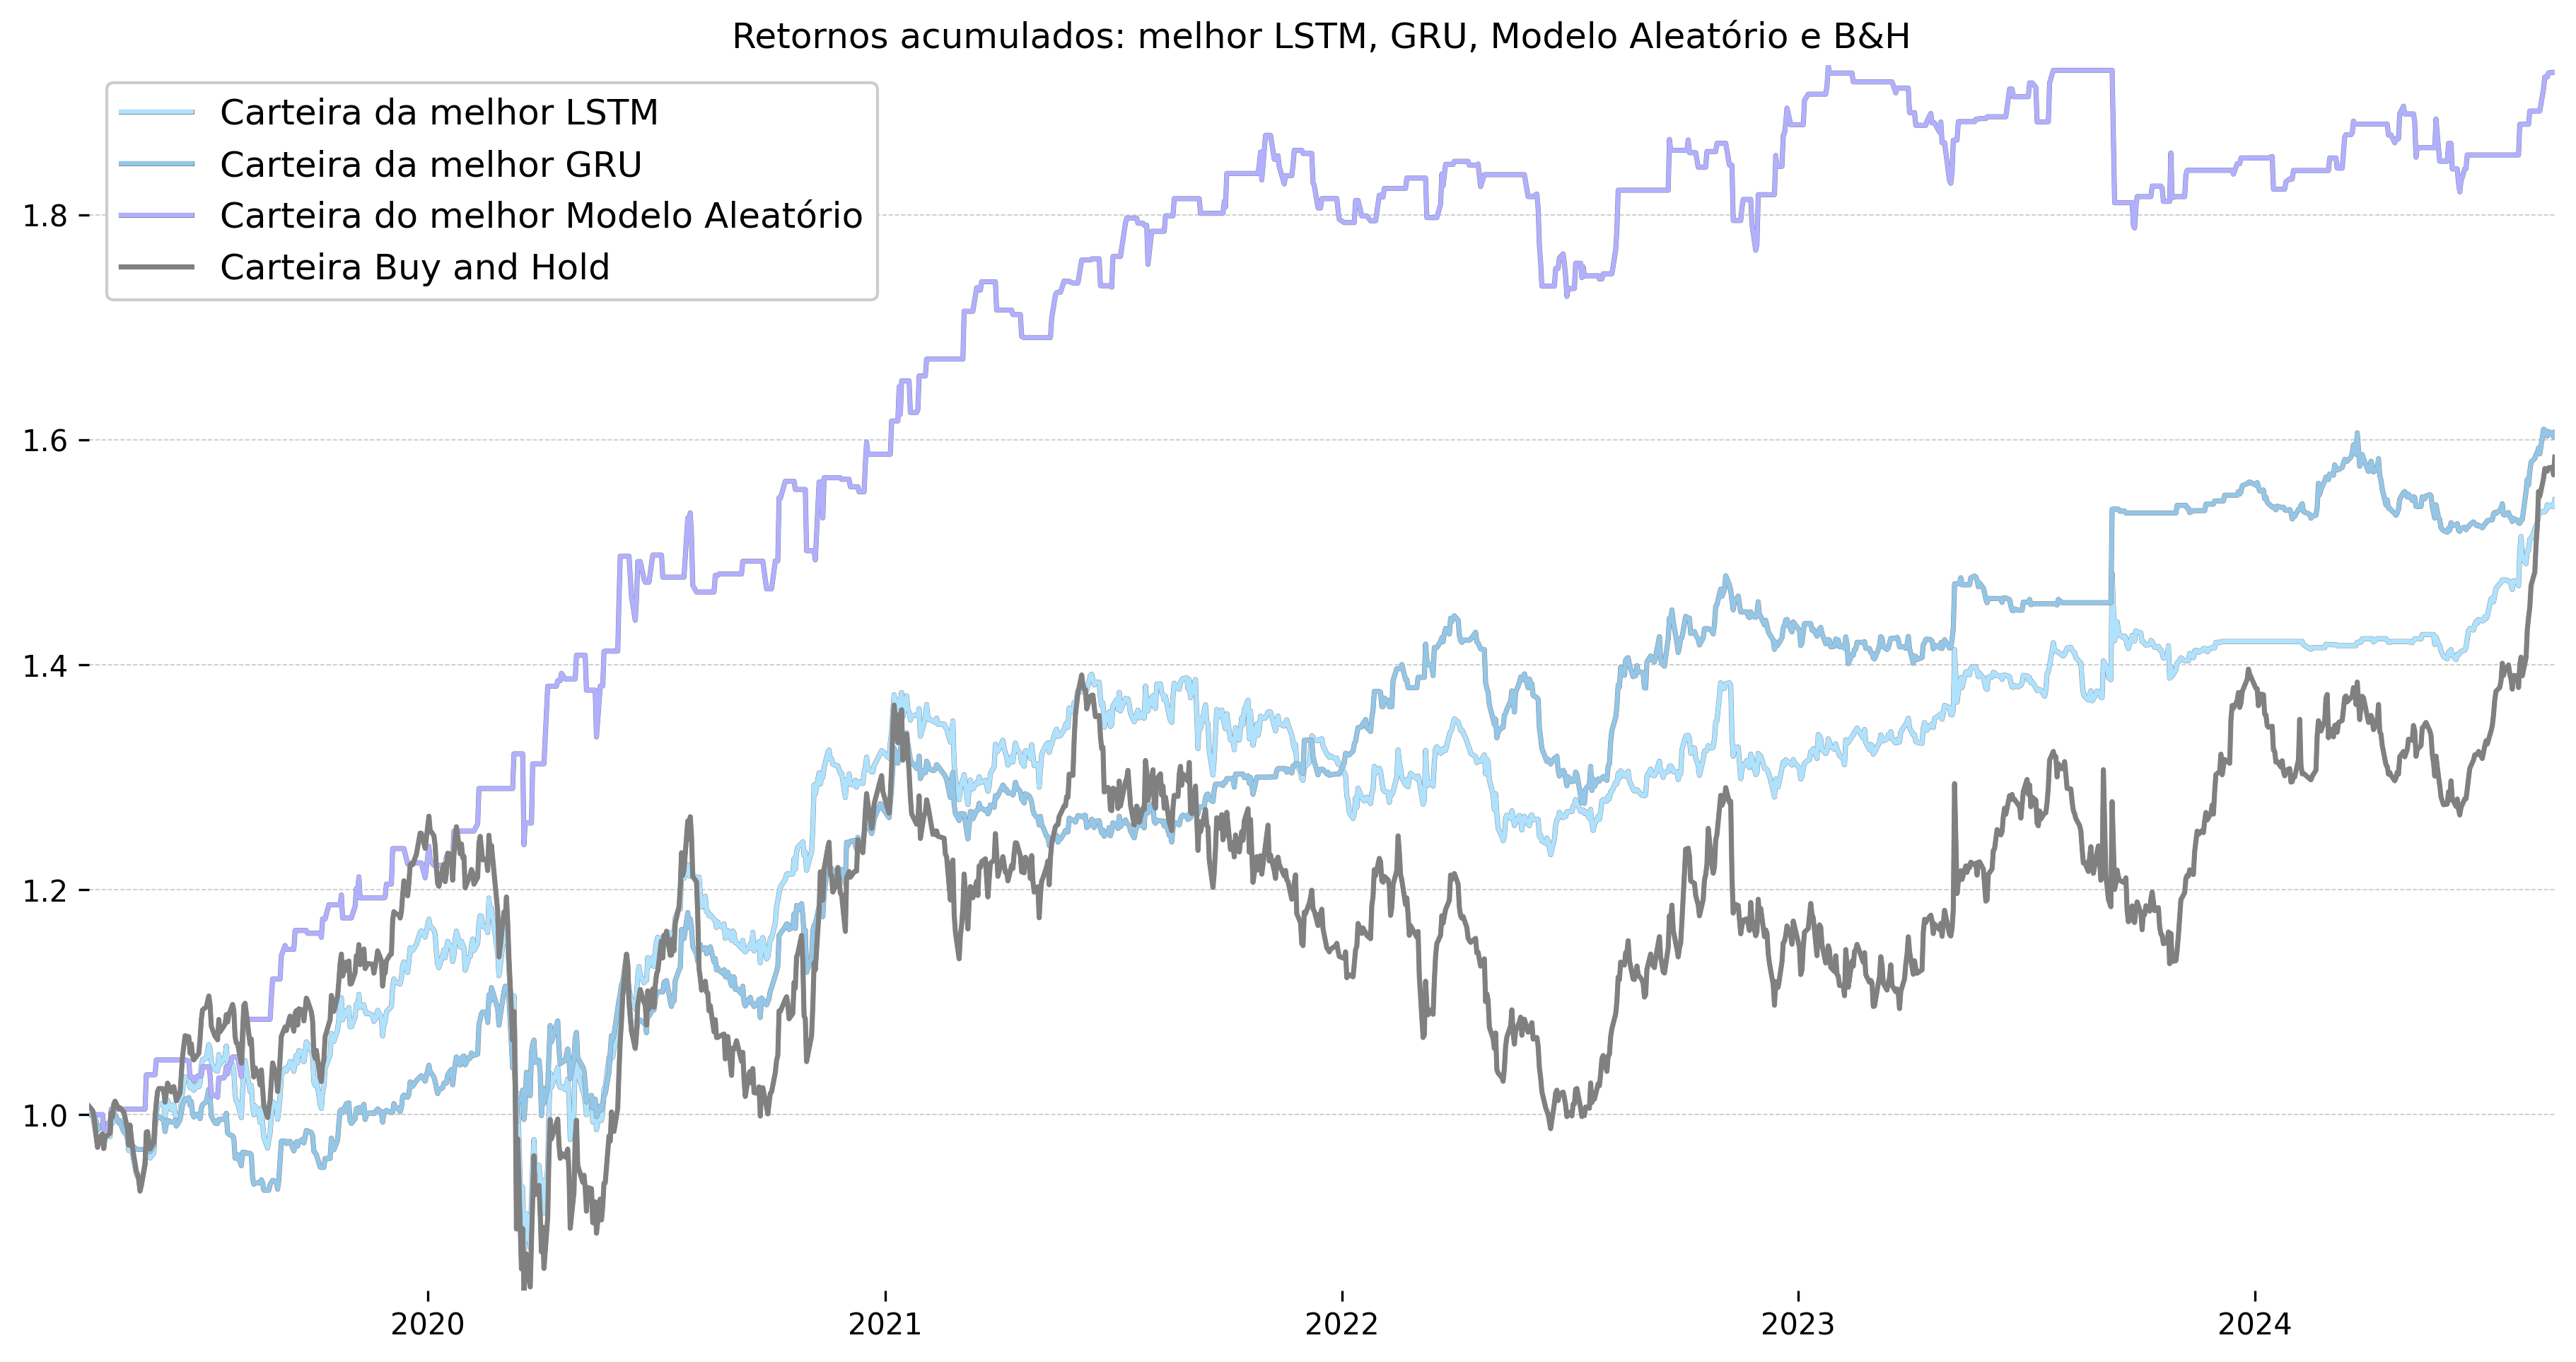

In [8]:
plot_many_returns_series(
    [cuml_perf_lstm_01, cuml_perf_gru_1, cuml_perf_rg_1, buy_and_hold_cuml_returns],
    ["Carteira da melhor LSTM", "Carteira da melhor GRU", "Carteira do melhor Modelo Aleatório", "Carteira Buy and Hold"], 
    daily_returns.index,
    [model_colors["LSTM"], model_colors["GRU"], model_colors["MA"], model_colors["B&H"]],
    "Retornos acumulados: melhor LSTM, GRU, Modelo Aleatório e B&H",
)

## Tentativa de extração de um comitê

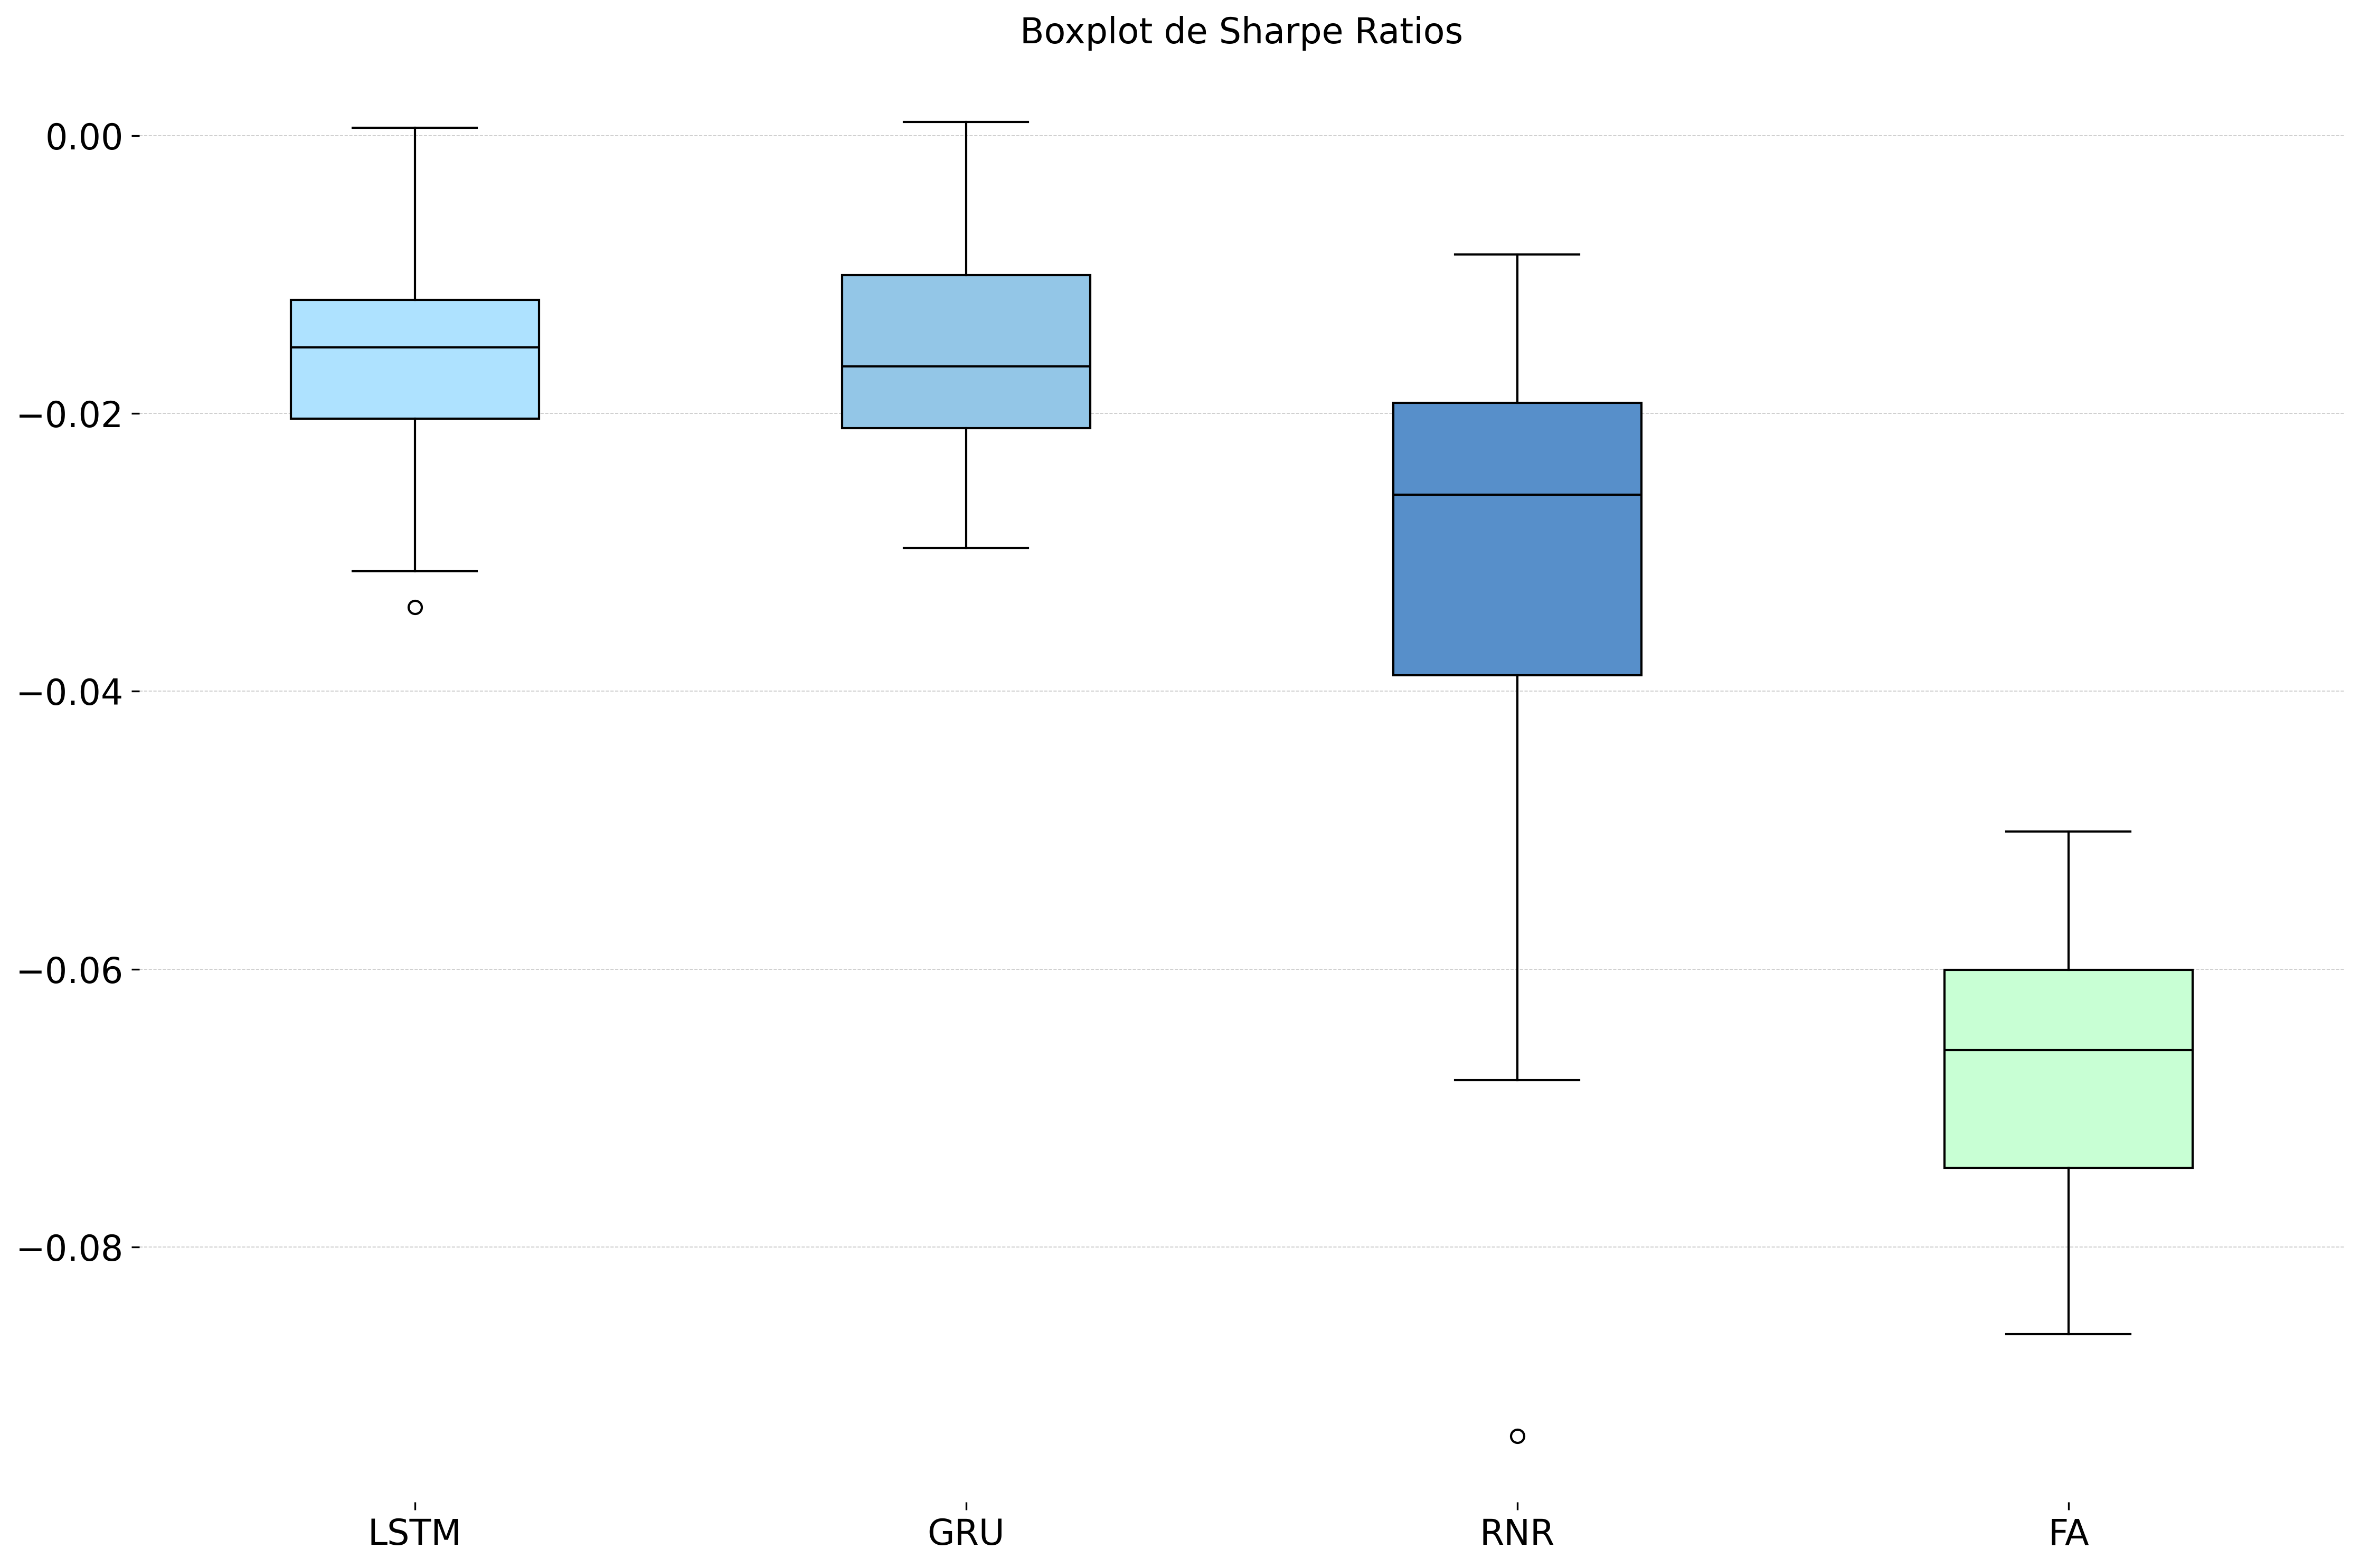

In [9]:
plot_distribution_and_stddev([
    lstm_sharpes_1,
    gru_sharpes_1,
    rnn_sharpes_1,
    rf_sharpes_1
],
"Sharpe Ratios",
legend_loc="lower right",
legend_size=16
)

In [10]:
print_statistics_table_for_series([
    lstm_sharpes_1,
    gru_sharpes_1,
    rnn_sharpes_1,
    rf_sharpes_1
])

+--------+---------+---------+---------+---------+---------------+--------+
| modelo |  média  | mediana |   max   |   min   | desvio padrão | range  |
+--------+---------+---------+---------+---------+---------------+--------+
|  LSTM  | -0.0162 | -0.0153 |  0.0006 | -0.0340 |     0.0080    | 0.0345 |
|  GRU   | -0.0163 | -0.0166 |  0.0010 | -0.0297 |     0.0075    | 0.0307 |
|  RNR   | -0.0308 | -0.0258 | -0.0086 | -0.0936 |     0.0181    | 0.0850 |
|   FA   | -0.0669 | -0.0658 | -0.0501 | -0.0863 |     0.0102    | 0.0362 |
+--------+---------+---------+---------+---------+---------------+--------+


Os Sharpe Ratios médios mais altos são da LSTM, GRU e RNR, e a média do FA é o dobro do pior dos 3 primeiros, ainda mais abaixo. Ainda assim será aplicado um teste ANOVA ou alternativa não paramétrica para verificar diferenças entre os grupos

### Verificando diferença entre as médias dos grupos para extrair o comitê

In [11]:
list_of_sharpes = [
    lstm_sharpes_1,
    gru_sharpes_1,
    rnn_sharpes_1,
    rf_sharpes_1
]

models_test_sharpes = ["LSTM", "GRU", "RNR", "FA"]

Shapiro-Wilk Statistic: 0.9672112211326716
P-Value: 0.46595524440879377
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9790005377475343
P-Value: 0.7983973039138849
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.8282337483050186
P-Value: 0.00022432710917325846
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal


Shapiro-Wilk Statistic: 0.9637144102390623
P-Value: 0.38400770781191523
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution




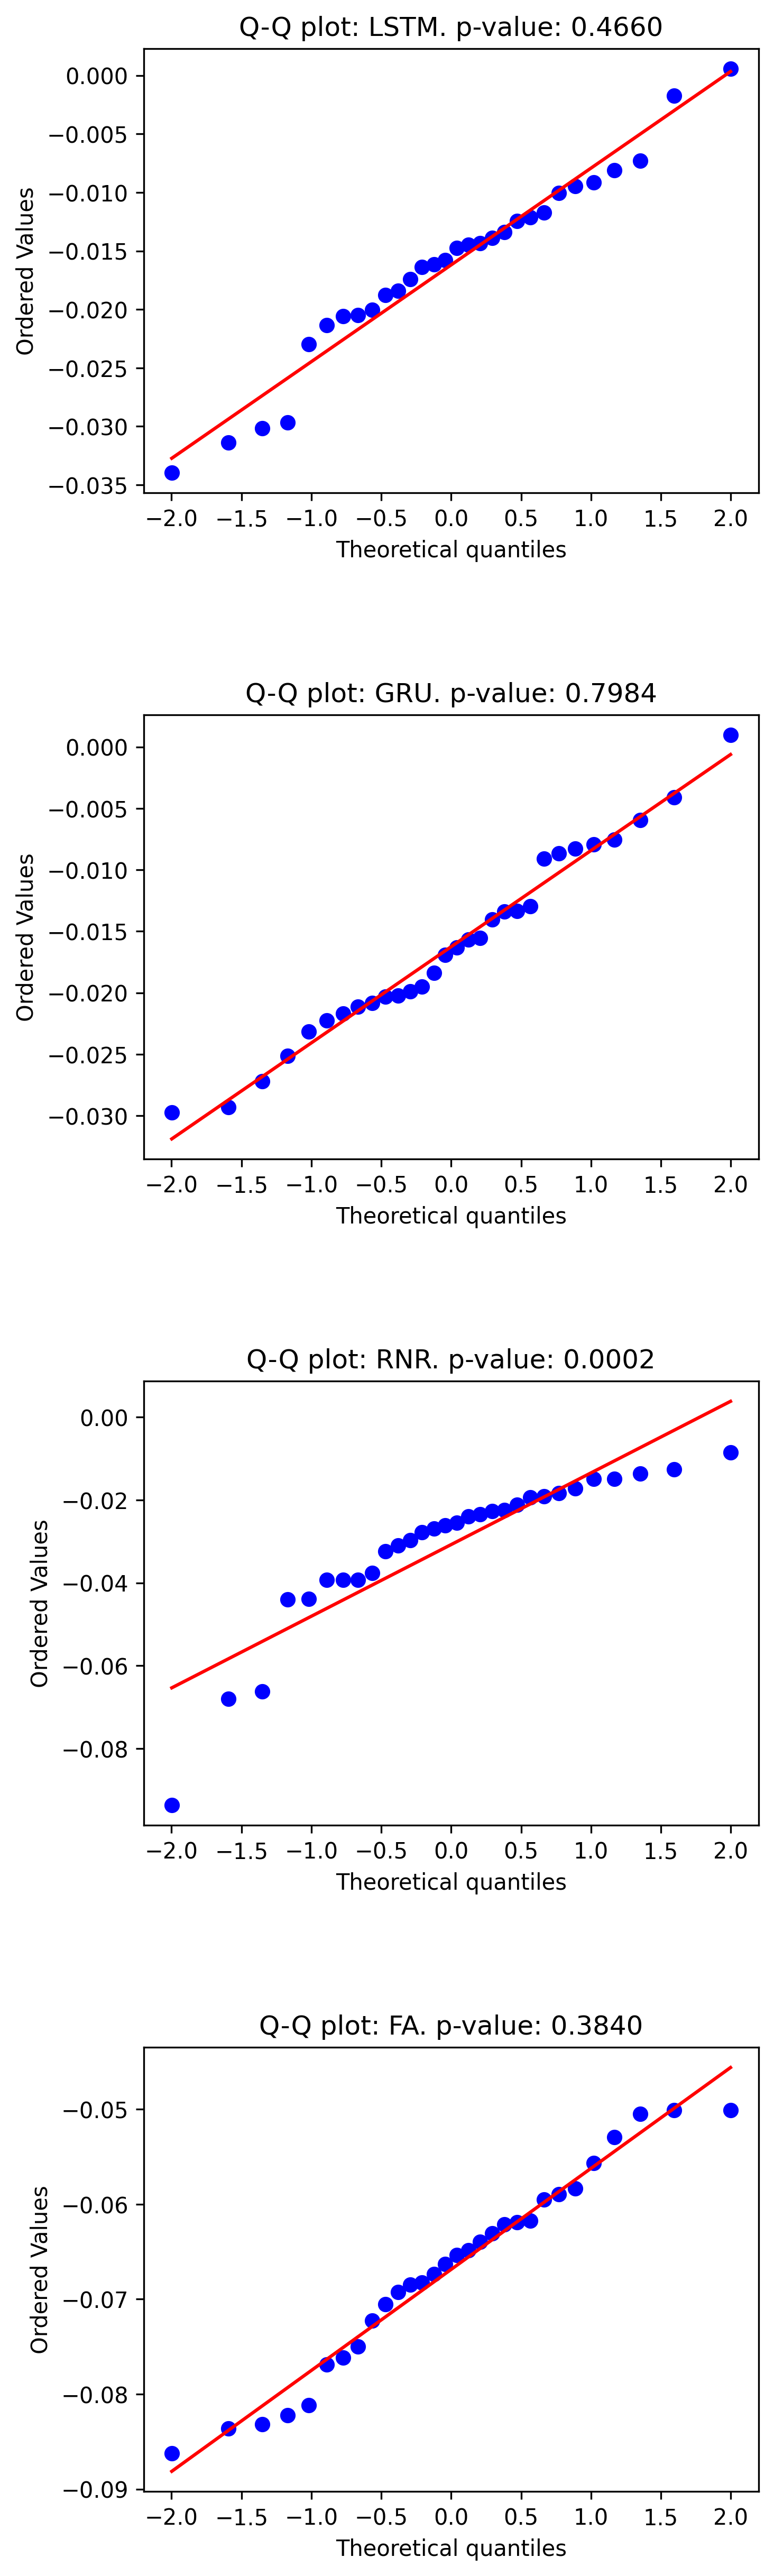

In [12]:
subplot_size = 5 

num_dists = len(list_of_sharpes)
fig_height = subplot_size * num_dists
fig_width = subplot_size

plt.figure(figsize=(fig_width, fig_height))

for i, dist in enumerate(list_of_sharpes):

    _, p_value = shapiro_wilk_gaussian_test(dist)
    print("")
    print("")

    mean = np.array(dist).mean()
    std = np.array(dist).std()

    plt.subplot(len(list_of_sharpes), 1, i+1)
    plt.axis(True)
    probplot(dist, dist="norm", plot=plt)
    # plt.title(f"{list_of_models[i]}; Mean: {mean:.6f}; Stddev: {std:.6f}")
    plt.title(f"Q-Q plot: {models_test_sharpes[i]}. p-value: {p_value:.4f}")
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

Será utilizado o teste de Kruskal-Wallis já que nem todas as distribuições pode se assumir que vieram de uma normal

In [13]:
kruskal_wallis_test(list_of_sharpes)

H-statistic: 74.25272727272733
p-value: 5.239097217629397e-16
There is a significant difference between at least two groups for an alpha of 0.05


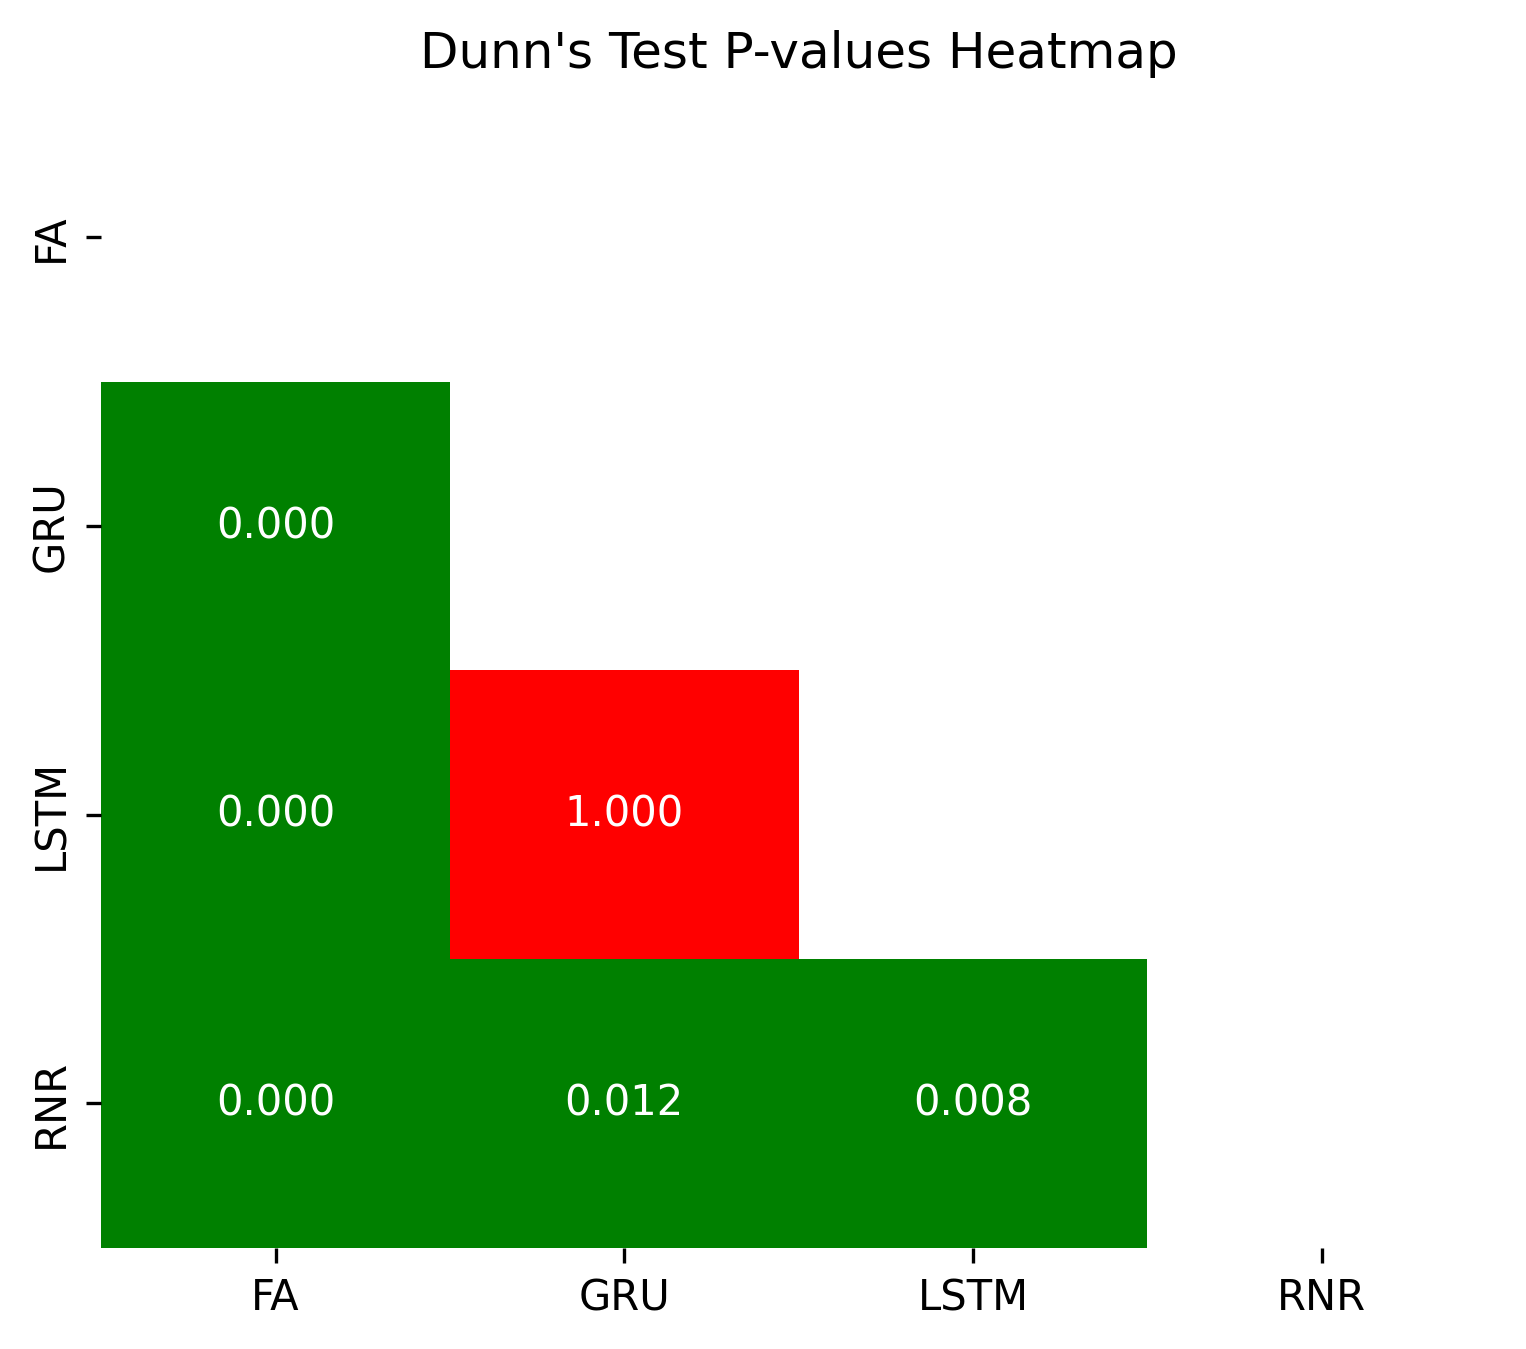

In [14]:
data = np.concatenate([dist for dist in list_of_sharpes])
groups = (["LSTM"] * len(lstm_sharpes_1) + ["GRU"] * len(gru_sharpes_1) +
          ["RNR"] * len(rnn_sharpes_1) + ["FA"] * len(rf_sharpes_1))

df = pd.DataFrame({"Value": data, "Group": groups})

# Dunn’s post hoc test with Bonferroni correction
posthoc = sp.posthoc_dunn(df, val_col="Value", group_col="Group", p_adjust="bonferroni")

# Define custom colormap: Green for p < 0.5, Red otherwise
colors = ["green", "red"]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0, 0.05, 1], cmap.N)  # Boundary at p = 0.05

# Plot heatmap with colors based on significance but showing actual p-values
plt.figure(figsize=(6,5))
ax = sns.heatmap(posthoc, annot=True, fmt=".3f", cmap=cmap, cbar=False, norm=norm, mask=np.triu(np.ones_like(posthoc, dtype=bool)))

plt.title("Dunn's Test P-values Heatmap")
plt.show()


Foi observado através do teste de Kruskal Wallis com correção de bonferroni que a observação do boxplot é confirmada: há diferença entre os grupos exceto entre a LSTM e a GRU. Portanto, as 3 redes neurais estão de fato localizadas acima da floresta aleatória

### Construindo o comitê

In [15]:
stocks = ["abev3", "bbdc3", "itsa3", "itub3", "wege3"]

In [16]:
len(results_lstm_1)
all_preds_lstm = {}
all_preds_gru = {}
all_preds_rnn = {}
for stock in stocks:
    all_preds_lstm[stock] = [result[stock][1] for result in results_lstm_1]
    all_preds_gru[stock] = [result[stock][1] for result in results_gru_1]
    all_preds_rnn[stock] = [result[stock][1] for result in results_rnn_1]

print(len(all_preds_lstm["abev3"]))
print(len(list(all_preds_lstm["abev3"][0])))

all_preds_ensemble = {}
for stock in stocks:
    all_preds_ensemble[stock] = [[] for _ in range(len(all_preds_lstm["abev3"]))]

res_ensemble = []

for experiment in range(len(results_lstm_1)):
    partial_res = {}
    for stock in stocks:
        lstm = all_preds_lstm[stock][experiment]

        gru = all_preds_gru[stock][experiment]

        rnn = all_preds_rnn[stock][experiment]

        ensemble = [0 for _ in range(len(lstm))]
        
        for i in range(len(lstm)):
            triplet = [lstm[i], gru[i], rnn[i]]
            values = [list(item.values())[0] for item in triplet]
            if values.count(1) > values.count(0):
                ensemble[i] = {list(triplet[0].keys())[0]: 1}
            else:
                ensemble[i] = {list(triplet[0].keys())[0]: 0}

        preds_to_compute = [list(item.values())[0] for item in ensemble]
        grounds_to_compute = results_lstm_1[0][stock][0]["ground"]
        metrics = {
            "accuracy": accuracy_score(grounds_to_compute, preds_to_compute),
            "f1": f1_score(grounds_to_compute, preds_to_compute),
            "precision": precision_score(grounds_to_compute, preds_to_compute, zero_division=0),
            "recall": recall_score(grounds_to_compute, preds_to_compute),
        }
        partial_res[stock] = (metrics, ensemble)
    res_ensemble.append(partial_res)

30
1350


In [17]:
best_results_ensemble, cuml_perf_ensemble, max_sharpe_ensemble, best_exp_idx_ensemble = find_best_experiment(res_ensemble, daily_returns)

Selected exp number 13


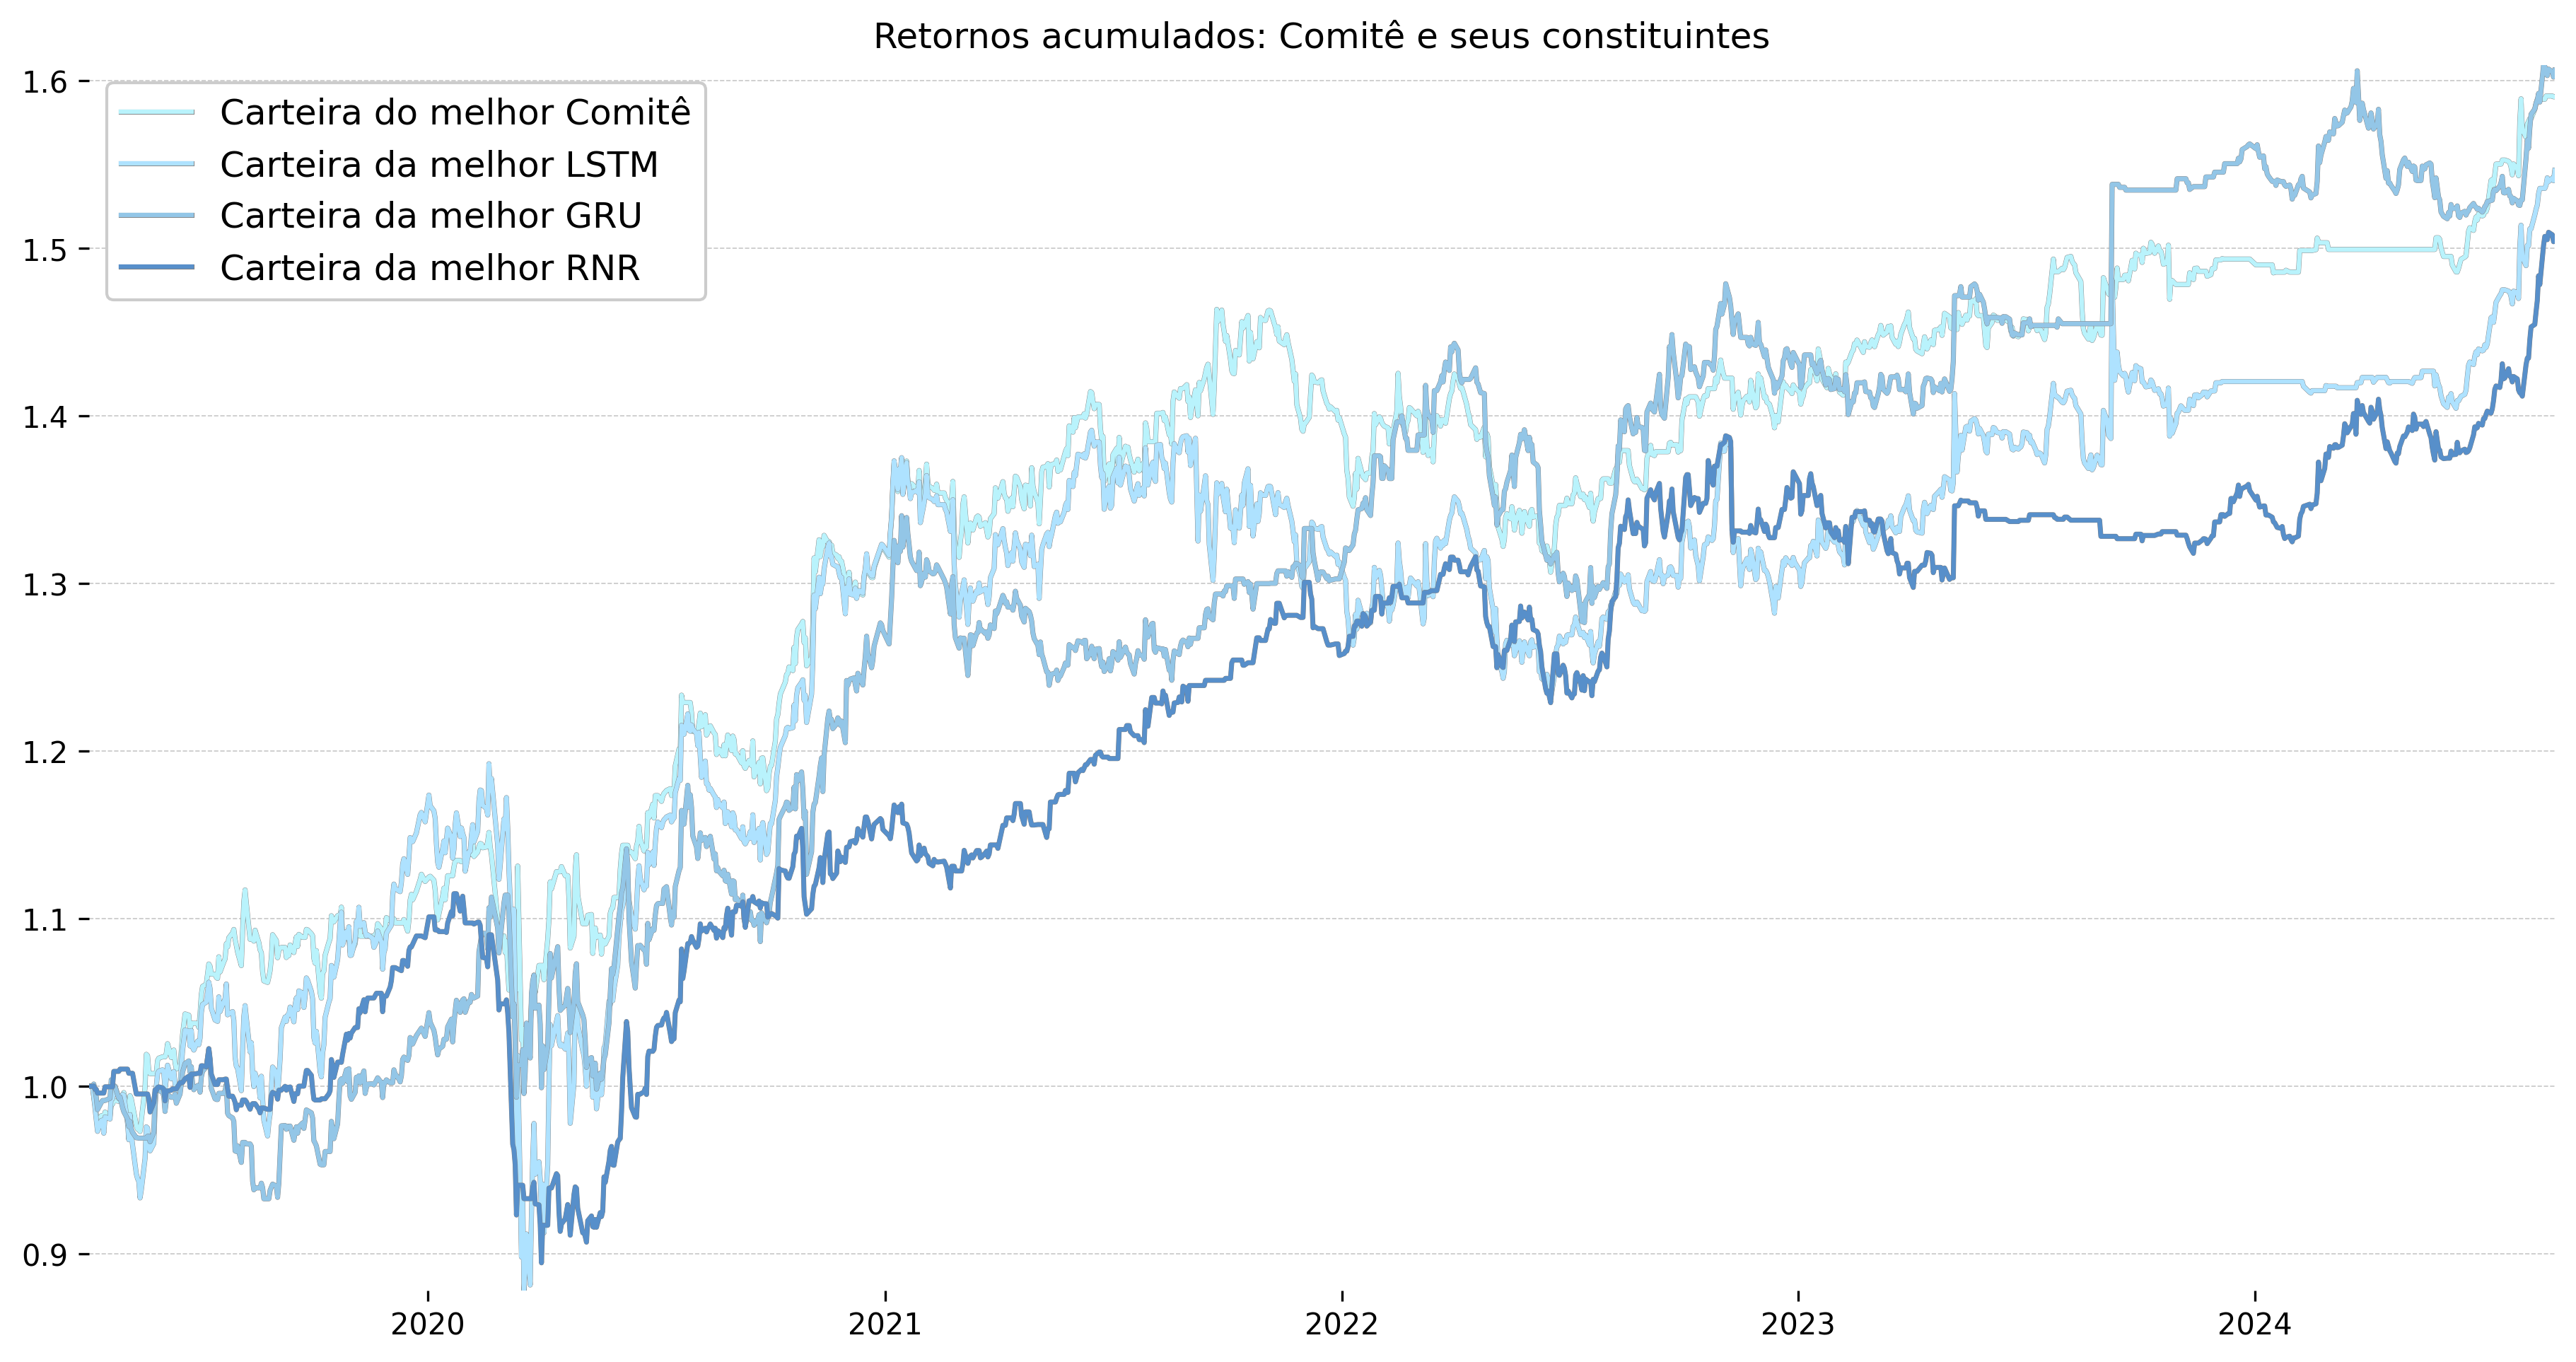

In [18]:
plot_many_returns_series(
    [cuml_perf_ensemble, cuml_perf_lstm_01, cuml_perf_gru_1, cuml_perf_rnn_1], 
    ["Carteira do melhor Comitê", "Carteira da melhor LSTM", "Carteira da melhor GRU", "Carteira da melhor RNR"], 
    daily_returns.index, 
    colors=[model_colors["Comitê"], model_colors["LSTM"], model_colors["GRU"], model_colors["RNR"]],
    title="Retornos acumulados: Comitê e seus constituintes"
)

In [19]:
ensemble_sharpes = get_sharpe_series_from_results(res_ensemble, daily_returns)
ensemble_accs = get_metric_distribution_from_results(res_ensemble, "accuracy")

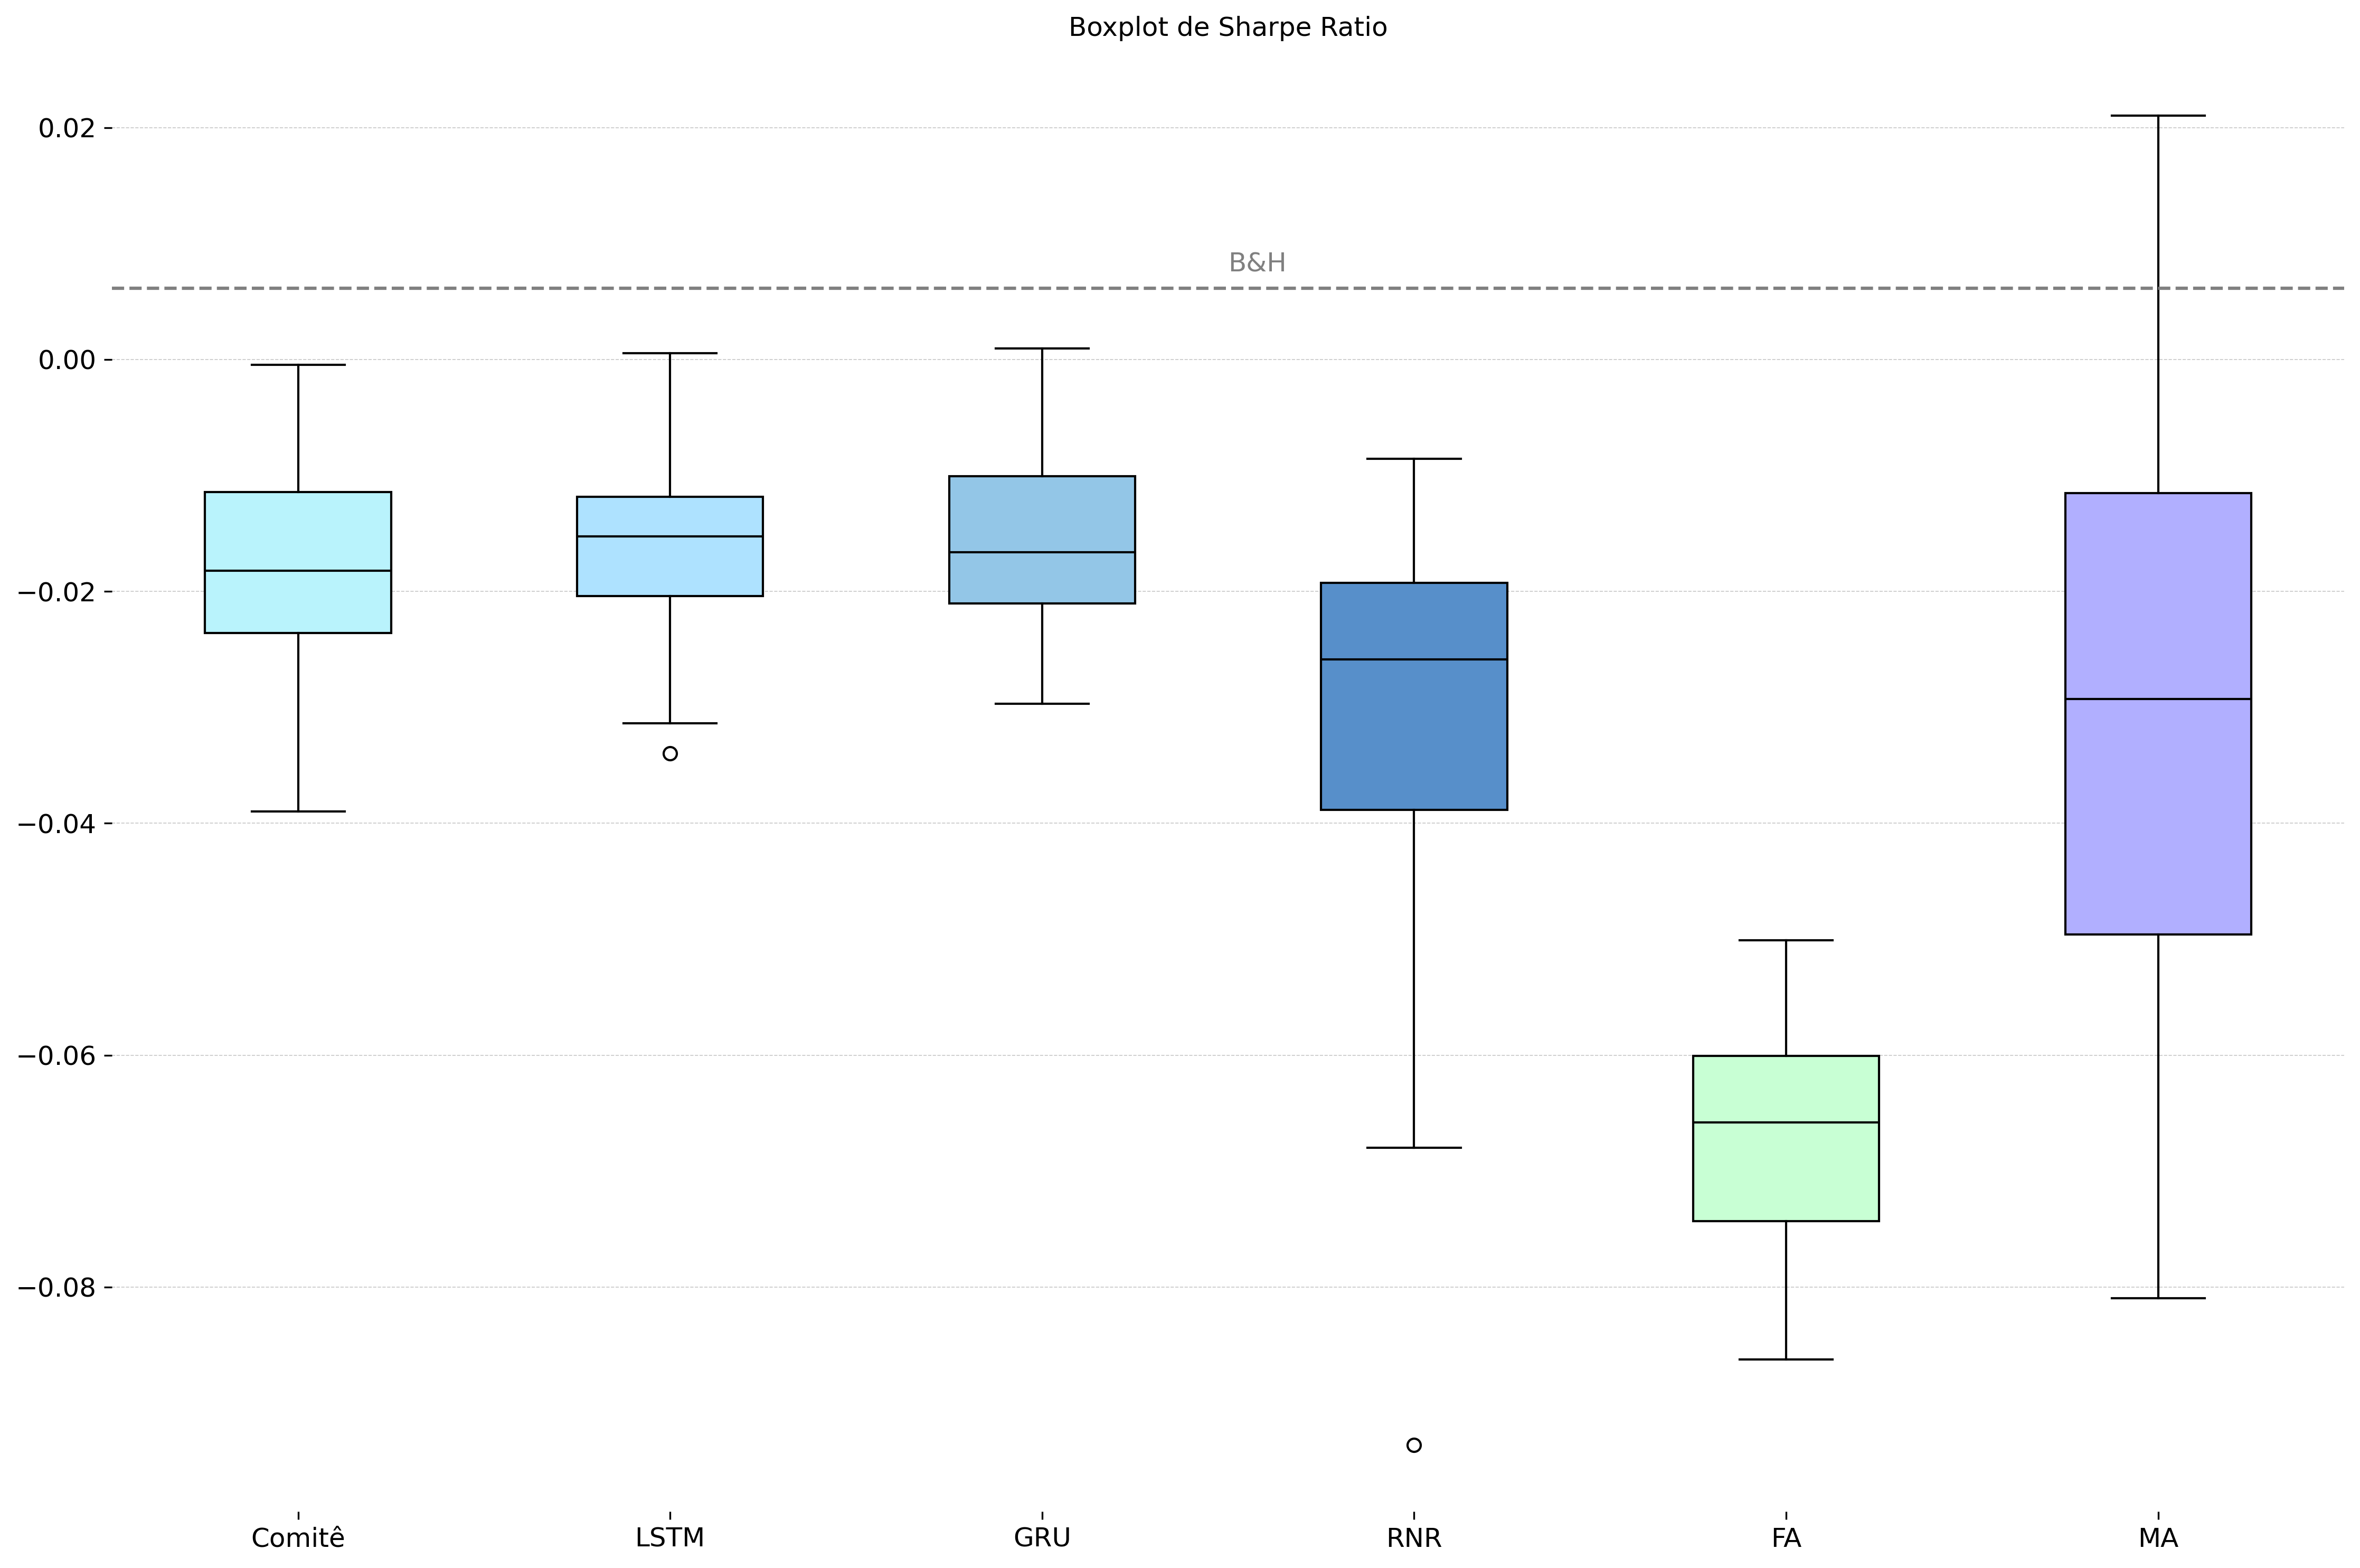

In [20]:
plot_distribution_and_stddev(
    [ensemble_sharpes, lstm_sharpes_1, gru_sharpes_1, rnn_sharpes_1, rf_sharpes_1, rg_sharpes_1], 
    metric="Sharpe Ratio", 
    models=["Comitê", "LSTM", "GRU", "RNR", "FA", "MA"],
    benchmark_value=buy_and_hold_sharpe,
    benchmark_color=model_colors["B&H"],
    benchmark_name="B&H"
)

In [21]:
print_statistics_table_for_series([ensemble_sharpes, lstm_sharpes_1, gru_sharpes_1, rnn_sharpes_1, rf_sharpes_1, rg_sharpes_1], models=["Comitê", "LSTM", "GRU", "RNR", "FA", "MA"])

+--------+---------+---------+---------+---------+---------------+--------+
| modelo |  média  | mediana |   max   |   min   | desvio padrão | range  |
+--------+---------+---------+---------+---------+---------------+--------+
| Comitê | -0.0176 | -0.0182 | -0.0004 | -0.0390 |     0.0088    | 0.0385 |
|  LSTM  | -0.0162 | -0.0153 |  0.0006 | -0.0340 |     0.0080    | 0.0345 |
|  GRU   | -0.0163 | -0.0166 |  0.0010 | -0.0297 |     0.0075    | 0.0307 |
|  RNR   | -0.0308 | -0.0258 | -0.0086 | -0.0936 |     0.0181    | 0.0850 |
|   FA   | -0.0669 | -0.0658 | -0.0501 | -0.0863 |     0.0102    | 0.0362 |
|   MA   | -0.0304 | -0.0293 |  0.0210 | -0.0810 |     0.0241    | 0.1020 |
+--------+---------+---------+---------+---------+---------------+--------+


In [22]:
kruskal_wallis_test([ensemble_sharpes, lstm_sharpes_1, gru_sharpes_1, rnn_sharpes_1, rf_sharpes_1, rg_sharpes_1])

H-statistic: 83.92842234499699
p-value: 1.2626595668004838e-16
There is a significant difference between at least two groups for an alpha of 0.05


In [23]:
list_of_sharpes = [ensemble_sharpes, lstm_sharpes_1, gru_sharpes_1, rnn_sharpes_1, rf_sharpes_1, rg_sharpes_1]

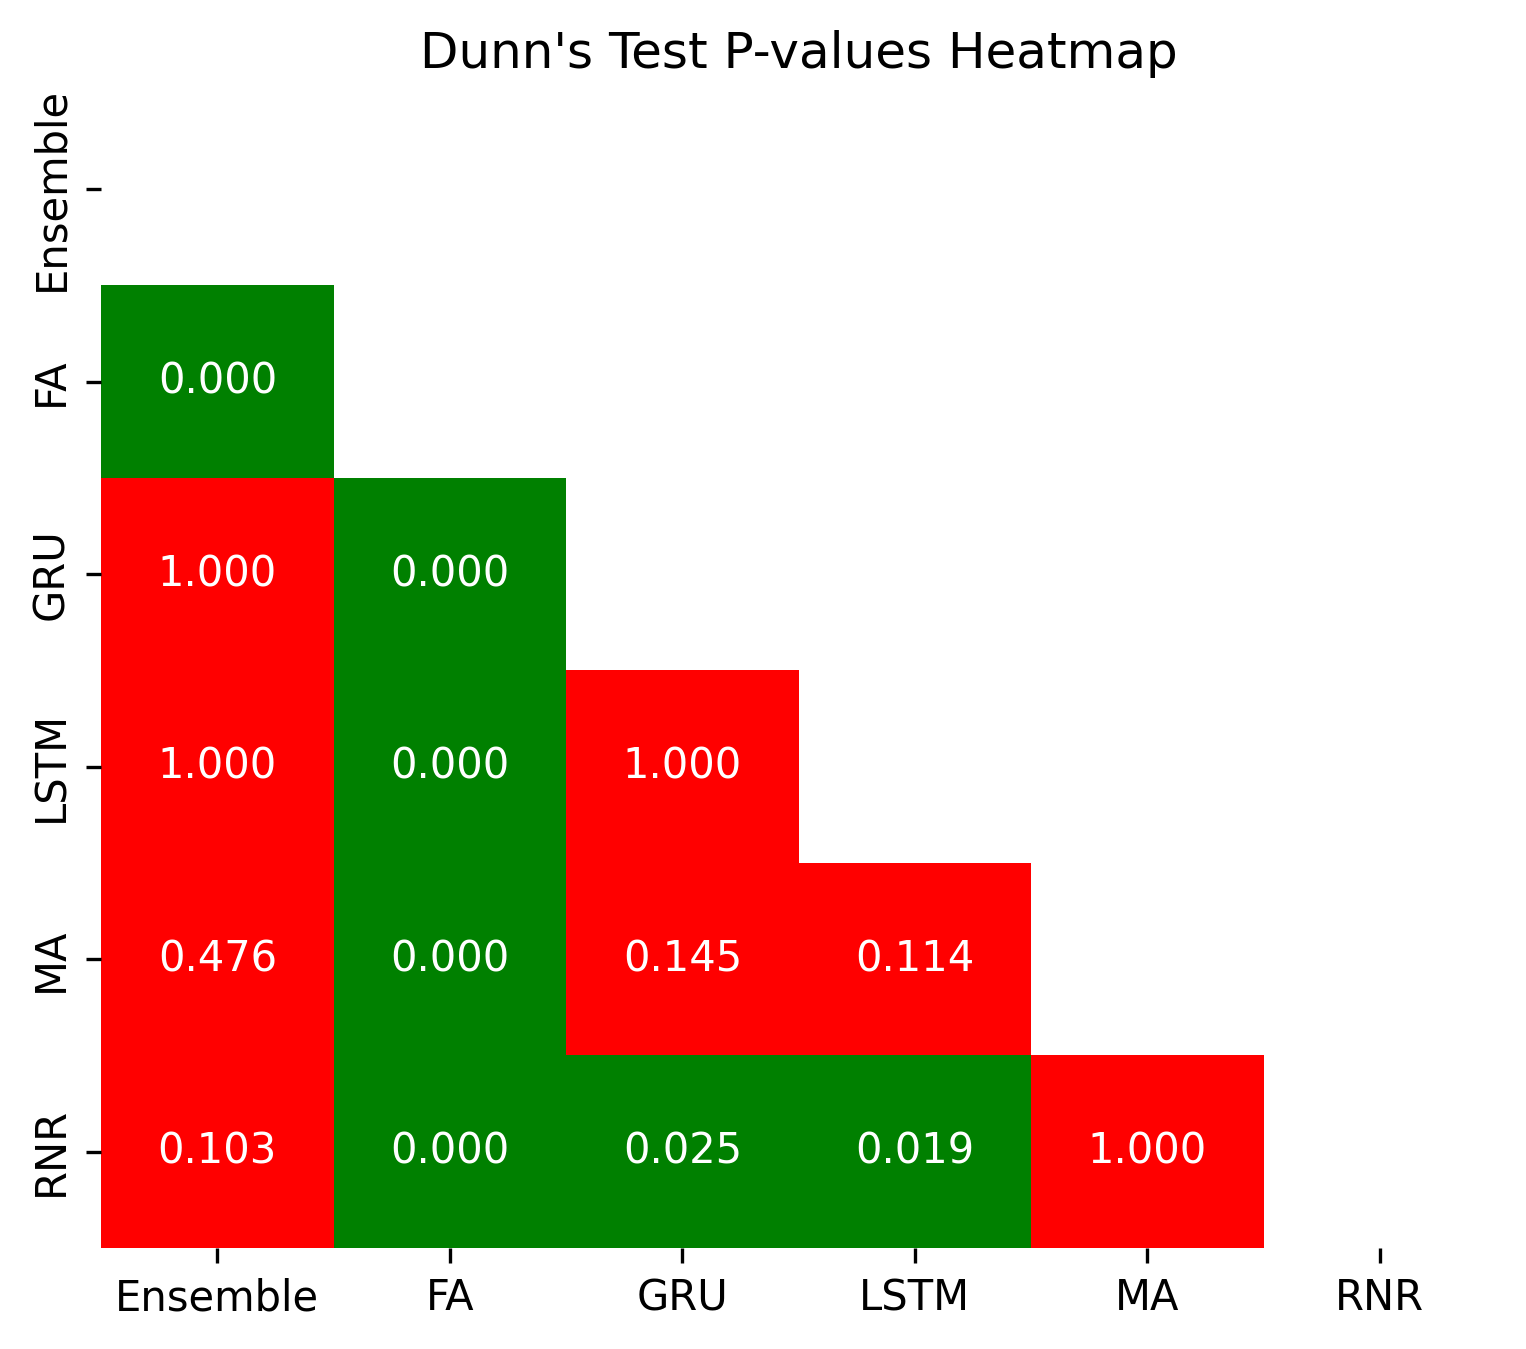

In [24]:
data = np.concatenate([dist for dist in list_of_sharpes])
groups = (["Ensemble"] * len(ensemble_sharpes) + ["LSTM"] * len(lstm_sharpes_1) + ["GRU"] * len(gru_sharpes_1) + ["RNR"] * len(rnn_sharpes_1) + ["FA"] * len(rf_sharpes_1) + ["MA"] * len(rg_sharpes_1))

df = pd.DataFrame({"Value": data, "Group": groups})

# Dunn’s post hoc test with Bonferroni correction
posthoc = sp.posthoc_dunn(df, val_col="Value", group_col="Group", p_adjust="bonferroni")

# Define custom colormap: Green for p < 0.5, Red otherwise
colors = ["green", "red"]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0, 0.05, 1], cmap.N)  # Boundary at p = 0.05

# Plot heatmap with colors based on significance but showing actual p-values
plt.figure(figsize=(6,5))
ax = sns.heatmap(posthoc, annot=True, fmt=".3f", cmap=cmap, cbar=False, norm=norm, mask=np.triu(np.ones_like(posthoc, dtype=bool)))

plt.title("Dunn's Test P-values Heatmap")
plt.show()

Não se observa diferença entre os sharpes do comitê e GRU, comitê e LSTM, GRU e LSTM e MA e RNR

## Acurácias

In [25]:
lstm_accs_1 = get_metric_distribution_from_results(results_lstm_1, "accuracy")
gru_accs_1 = get_metric_distribution_from_results(results_gru_1, "accuracy")
rnn_accs_1 = get_metric_distribution_from_results(results_rnn_1, "accuracy")
rf_accs_1 = get_metric_distribution_from_results(results_rf_1, "accuracy")
rg_accs_1 = get_metric_distribution_from_results(results_rg_1, "accuracy")

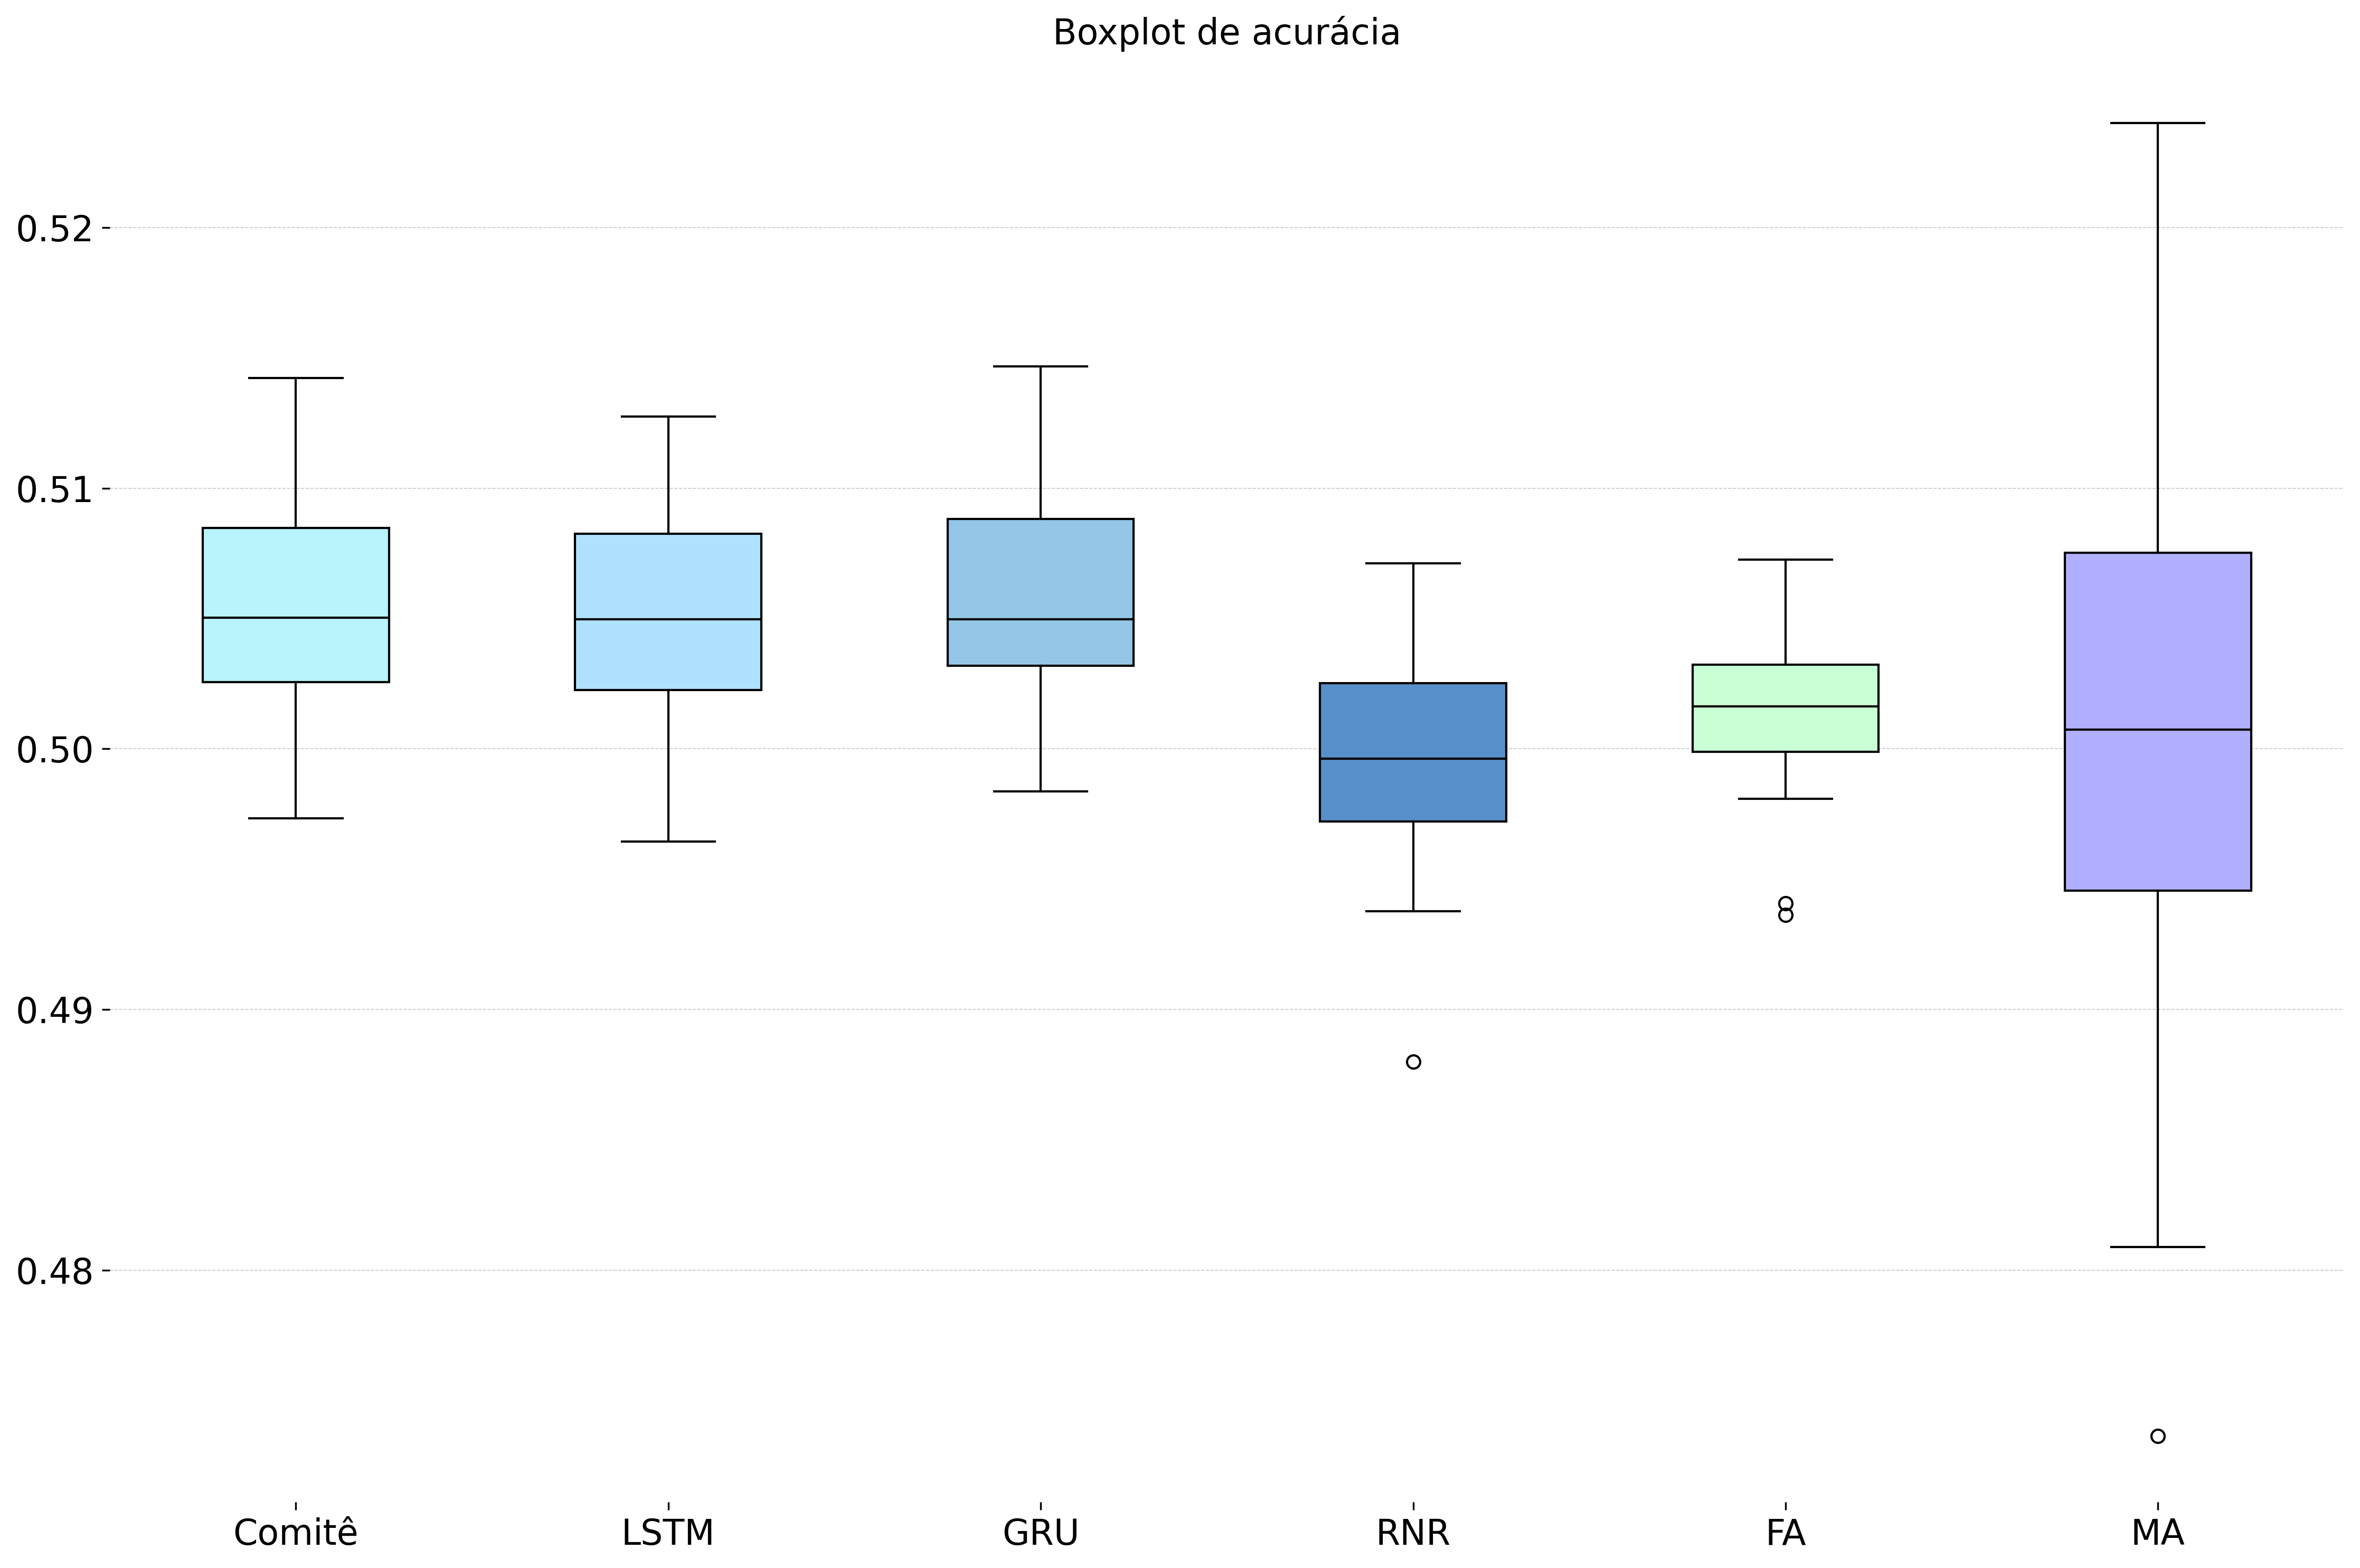

In [26]:
plot_distribution_and_stddev(
    [ensemble_accs, lstm_accs_1, gru_accs_1, rnn_accs_1, rf_accs_1, rg_accs_1], 
    metric="acurácia", 
    models=["Comitê", "LSTM", "GRU", "RNR", "FA", "MA"],
    legend_size=16
)

H-statistic: 37.11589125471127
p-value: 5.677460684579013e-07
There is a significant difference between at least two groups for an alpha of 0.05


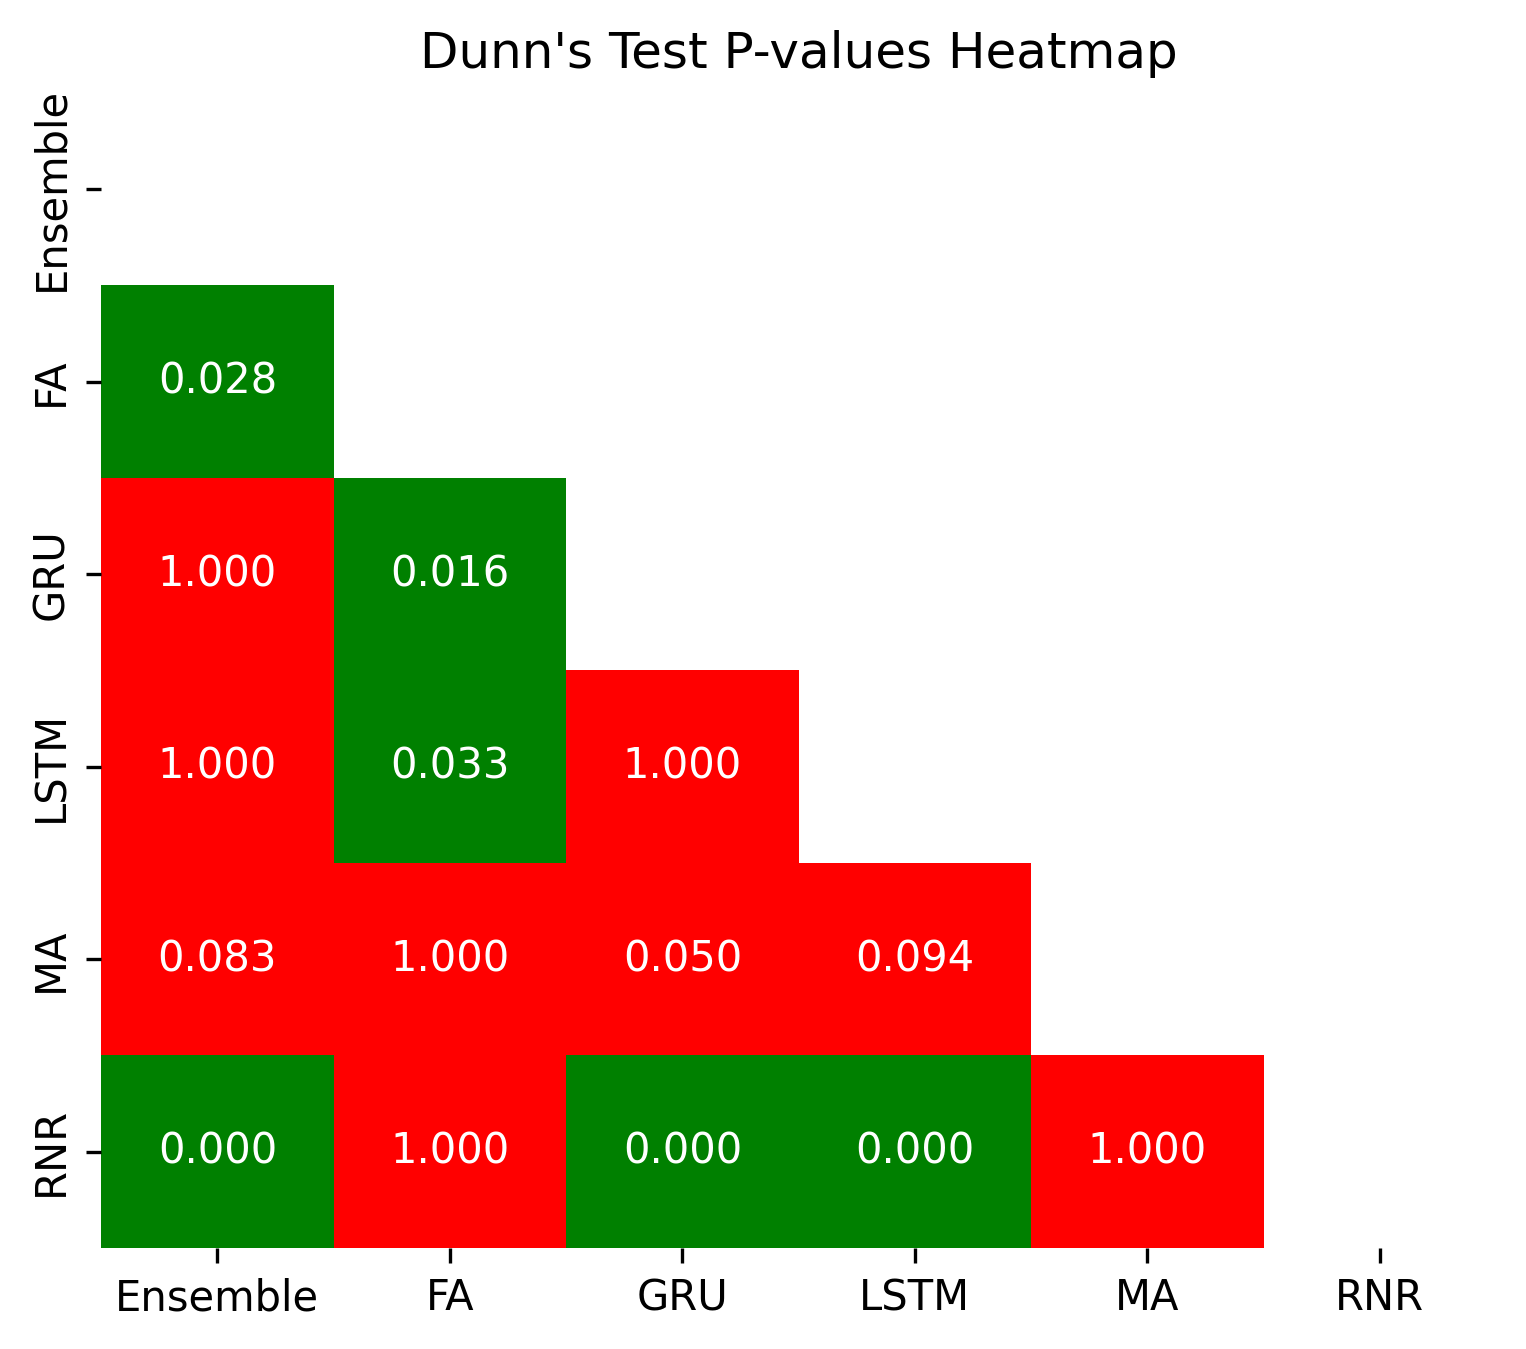

,Ensemble,FA,GRU,LSTM,MA,RNR
Ensemble,1.000000,0.028334,1.000000,1.000000,0.082768,0.000371
FA,0.028334,1.000000,0.016305,0.032782,1.000000,1.000000
GRU,1.000000,0.016305,1.000000,1.000000,0.050039,0.000180
LSTM,1.000000,0.032782,1.000000,1.000000,0.094491,0.000449
MA,0.082768,1.000000,0.050039,0.094491,1.000000,1.000000
RNR,0.000371,1.000000,0.000180,0.000449,1.000000,1.000000


In [27]:
kruskal_wallis_test([ensemble_accs, lstm_accs_1, gru_accs_1, rnn_accs_1, rf_accs_1, rg_accs_1])

data = np.concatenate([dist for dist in [ensemble_accs, lstm_accs_1, gru_accs_1, rnn_accs_1, rf_accs_1, rg_accs_1]])
groups = (["Ensemble"] * len(ensemble_accs) + 
          ["LSTM"] * len(lstm_accs_1) + 
          ["GRU"] * len(gru_accs_1) + 
          ["RNR"] * len(rnn_accs_1) + 
          ["FA"] * len(rf_accs_1) + 
          ["MA"] * len(rg_accs_1))

df = pd.DataFrame({"Value": data, "Group": groups})

# Dunn’s post hoc test with Bonferroni correction
posthoc = sp.posthoc_dunn(df, val_col="Value", group_col="Group", p_adjust="bonferroni")

# Define colormap where low values (significant) are green and high values are red
colors = ["green", "red"]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0, 0.05, 1], cmap.N)  # Boundary at p = 0.05

# Plot heatmap with colors based on significance but showing actual p-values
plt.figure(figsize=(6,5))
ax = sns.heatmap(posthoc, annot=True, fmt=".3f", cmap=cmap, cbar=False, norm=norm, mask=np.triu(np.ones_like(posthoc, dtype=bool)))

plt.title("Dunn's Test P-values Heatmap")
plt.show()

posthoc

In [28]:
print_statistics_table_for_series([ensemble_accs, lstm_accs_1, gru_accs_1, rnn_accs_1, rf_accs_1, rg_accs_1], ["Comitê", "LSTM", "GRU", "RNR", "FA", "MA"])

+--------+--------+---------+--------+--------+---------------+--------+
| modelo | média  | mediana |  max   |  min   | desvio padrão | range  |
+--------+--------+---------+--------+--------+---------------+--------+
| Comitê | 0.5053 |  0.5050 | 0.5142 | 0.4973 |     0.0041    | 0.0169 |
|  LSTM  | 0.5053 |  0.5050 | 0.5127 | 0.4964 |     0.0041    | 0.0163 |
|  GRU   | 0.5056 |  0.5050 | 0.5147 | 0.4984 |     0.0040    | 0.0163 |
|  RNR   | 0.4998 |  0.4996 | 0.5071 | 0.4880 |     0.0042    | 0.0191 |
|   FA   | 0.5016 |  0.5016 | 0.5073 | 0.4936 |     0.0031    | 0.0136 |
|   MA   | 0.5006 |  0.5007 | 0.5240 | 0.4736 |     0.0117    | 0.0504 |
+--------+--------+---------+--------+--------+---------------+--------+


In [29]:
abev3_accuracies_lstm = []
bbdc3_accuracies_lstm = []
itsa3_accuracies_lstm = []
itub3_accuracies_lstm = []
wege3_accuracies_lstm = []

for res_lstm in results_lstm_1:
    abev3_accuracies_lstm.append(res_lstm["abev3"][0]["accuracy"])
    bbdc3_accuracies_lstm.append(res_lstm["bbdc3"][0]["accuracy"])
    itsa3_accuracies_lstm.append(res_lstm["itsa3"][0]["accuracy"])
    itub3_accuracies_lstm.append(res_lstm["itub3"][0]["accuracy"])
    wege3_accuracies_lstm.append(res_lstm["wege3"][0]["accuracy"])

abev3_accuracies_gru = []
bbdc3_accuracies_gru = []
itsa3_accuracies_gru = []
itub3_accuracies_gru = []
wege3_accuracies_gru = []

for res_gru in results_gru_1:
    abev3_accuracies_gru.append(res_gru["abev3"][0]["accuracy"])
    bbdc3_accuracies_gru.append(res_gru["bbdc3"][0]["accuracy"])
    itsa3_accuracies_gru.append(res_gru["itsa3"][0]["accuracy"])
    itub3_accuracies_gru.append(res_gru["itub3"][0]["accuracy"])
    wege3_accuracies_gru.append(res_gru["wege3"][0]["accuracy"])

abev3_accuracies_rnn = []
bbdc3_accuracies_rnn = []
itsa3_accuracies_rnn = []
itub3_accuracies_rnn = []
wege3_accuracies_rnn = []

for res_rnn in results_rnn_1:
    abev3_accuracies_rnn.append(res_rnn["abev3"][0]["accuracy"])
    bbdc3_accuracies_rnn.append(res_rnn["bbdc3"][0]["accuracy"])
    itsa3_accuracies_rnn.append(res_rnn["itsa3"][0]["accuracy"])
    itub3_accuracies_rnn.append(res_rnn["itub3"][0]["accuracy"])
    wege3_accuracies_rnn.append(res_rnn["wege3"][0]["accuracy"])

abev3_accuracies_rf = []
bbdc3_accuracies_rf = []
itsa3_accuracies_rf = []
itub3_accuracies_rf = []
wege3_accuracies_rf = []

for res_rf in results_rf_1:
    abev3_accuracies_rf.append(res_rf["abev3"][0]["accuracy"])
    bbdc3_accuracies_rf.append(res_rf["bbdc3"][0]["accuracy"])
    itsa3_accuracies_rf.append(res_rf["itsa3"][0]["accuracy"])
    itub3_accuracies_rf.append(res_rf["itub3"][0]["accuracy"])
    wege3_accuracies_rf.append(res_rf["wege3"][0]["accuracy"])

abev3_accuracies_rg = []
bbdc3_accuracies_rg = []
itsa3_accuracies_rg = []
itub3_accuracies_rg = []
wege3_accuracies_rg = []

for res_rg in results_rg_1:
    abev3_accuracies_rg.append(res_rg["abev3"][0]["accuracy"])
    bbdc3_accuracies_rg.append(res_rg["bbdc3"][0]["accuracy"])
    itsa3_accuracies_rg.append(res_rg["itsa3"][0]["accuracy"])
    itub3_accuracies_rg.append(res_rg["itub3"][0]["accuracy"])
    wege3_accuracies_rg.append(res_rg["wege3"][0]["accuracy"])

abev3_accuracies_ensemble = []
bbdc3_accuracies_ensemble = []
itsa3_accuracies_ensemble = []
itub3_accuracies_ensemble = []
wege3_accuracies_ensemble = []

for res_ens in res_ensemble:
    abev3_accuracies_ensemble.append(res_ens["abev3"][0]["accuracy"])
    bbdc3_accuracies_ensemble.append(res_ens["bbdc3"][0]["accuracy"])
    itsa3_accuracies_ensemble.append(res_ens["itsa3"][0]["accuracy"])
    itub3_accuracies_ensemble.append(res_ens["itub3"][0]["accuracy"])
    wege3_accuracies_ensemble.append(res_ens["wege3"][0]["accuracy"])

abev3_accuracies_rg = []
bbdc3_accuracies_rg = []
itsa3_accuracies_rg = []
itub3_accuracies_rg = []
wege3_accuracies_rg = []
for res_rg in results_rg_1:
    abev3_accuracies_rg.append(res_rg["abev3"][0]["accuracy"])
    bbdc3_accuracies_rg.append(res_rg["bbdc3"][0]["accuracy"])
    itsa3_accuracies_rg.append(res_rg["itsa3"][0]["accuracy"])
    itub3_accuracies_rg.append(res_rg["itub3"][0]["accuracy"])
    wege3_accuracies_rg.append(res_rg["wege3"][0]["accuracy"])

In [30]:
models_for_acc = [
    "Comitê",
    "LSTM",
    "GRU",
    "RNR",
    "FA",
    "MA"
]

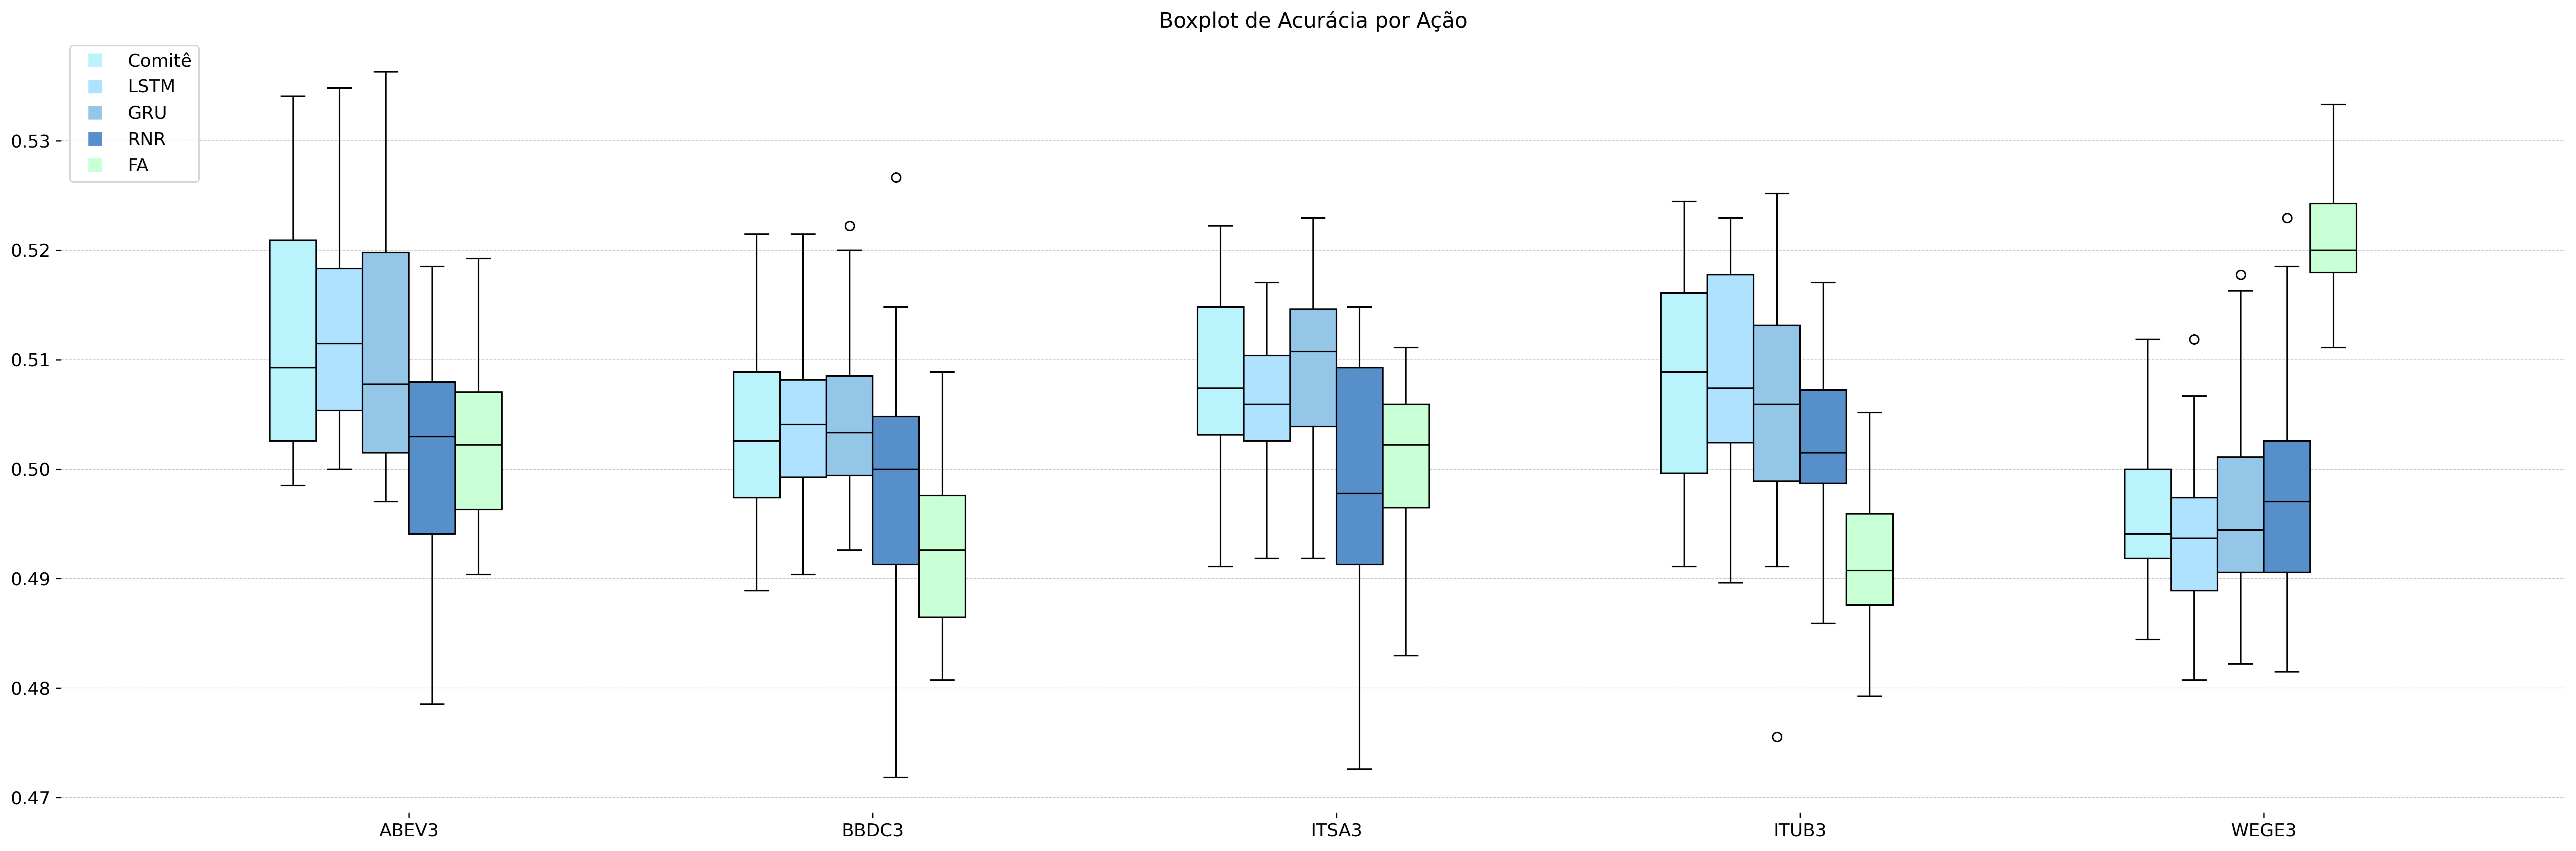

In [31]:
data = {
    "ABEV3": [abev3_accuracies_ensemble, abev3_accuracies_lstm, abev3_accuracies_gru, abev3_accuracies_rnn, abev3_accuracies_rf],
    "BBDC3": [bbdc3_accuracies_ensemble, bbdc3_accuracies_lstm, bbdc3_accuracies_gru, bbdc3_accuracies_rnn, bbdc3_accuracies_rf],
    "ITSA3": [itsa3_accuracies_ensemble, itsa3_accuracies_lstm, itsa3_accuracies_gru, itsa3_accuracies_rnn, itsa3_accuracies_rf],
    "ITUB3": [itub3_accuracies_ensemble, itub3_accuracies_lstm, itub3_accuracies_gru, itub3_accuracies_rnn, itub3_accuracies_rf],
    "WEGE3": [wege3_accuracies_ensemble, wege3_accuracies_lstm, wege3_accuracies_gru, wege3_accuracies_rnn, wege3_accuracies_rf],
}

plot_grouped_boxplot(data, metric="Acurácia")


Nenhum dos modelos se destaca em uma análise de acurácia ação por ação

## Retornos Acumulados

In [32]:
lstm_cuml_returns_dist = get_cuml_returns_dist(results_lstm_1, daily_returns)
gru_cuml_returns_dist = get_cuml_returns_dist(results_gru_1, daily_returns)
rnn_cuml_returns_dist = get_cuml_returns_dist(results_rnn_1, daily_returns)
rf_cuml_returns_dist = get_cuml_returns_dist(results_rf_1, daily_returns)
rg_cuml_returns_dist = get_cuml_returns_dist(results_rg_1, daily_returns)
ensemble_cuml_returns_dist = get_cuml_returns_dist(res_ensemble, daily_returns)

In [33]:
list_of_models = ["Comitê", "LSTM", "GRU", "RNR", "FA", "MA"]

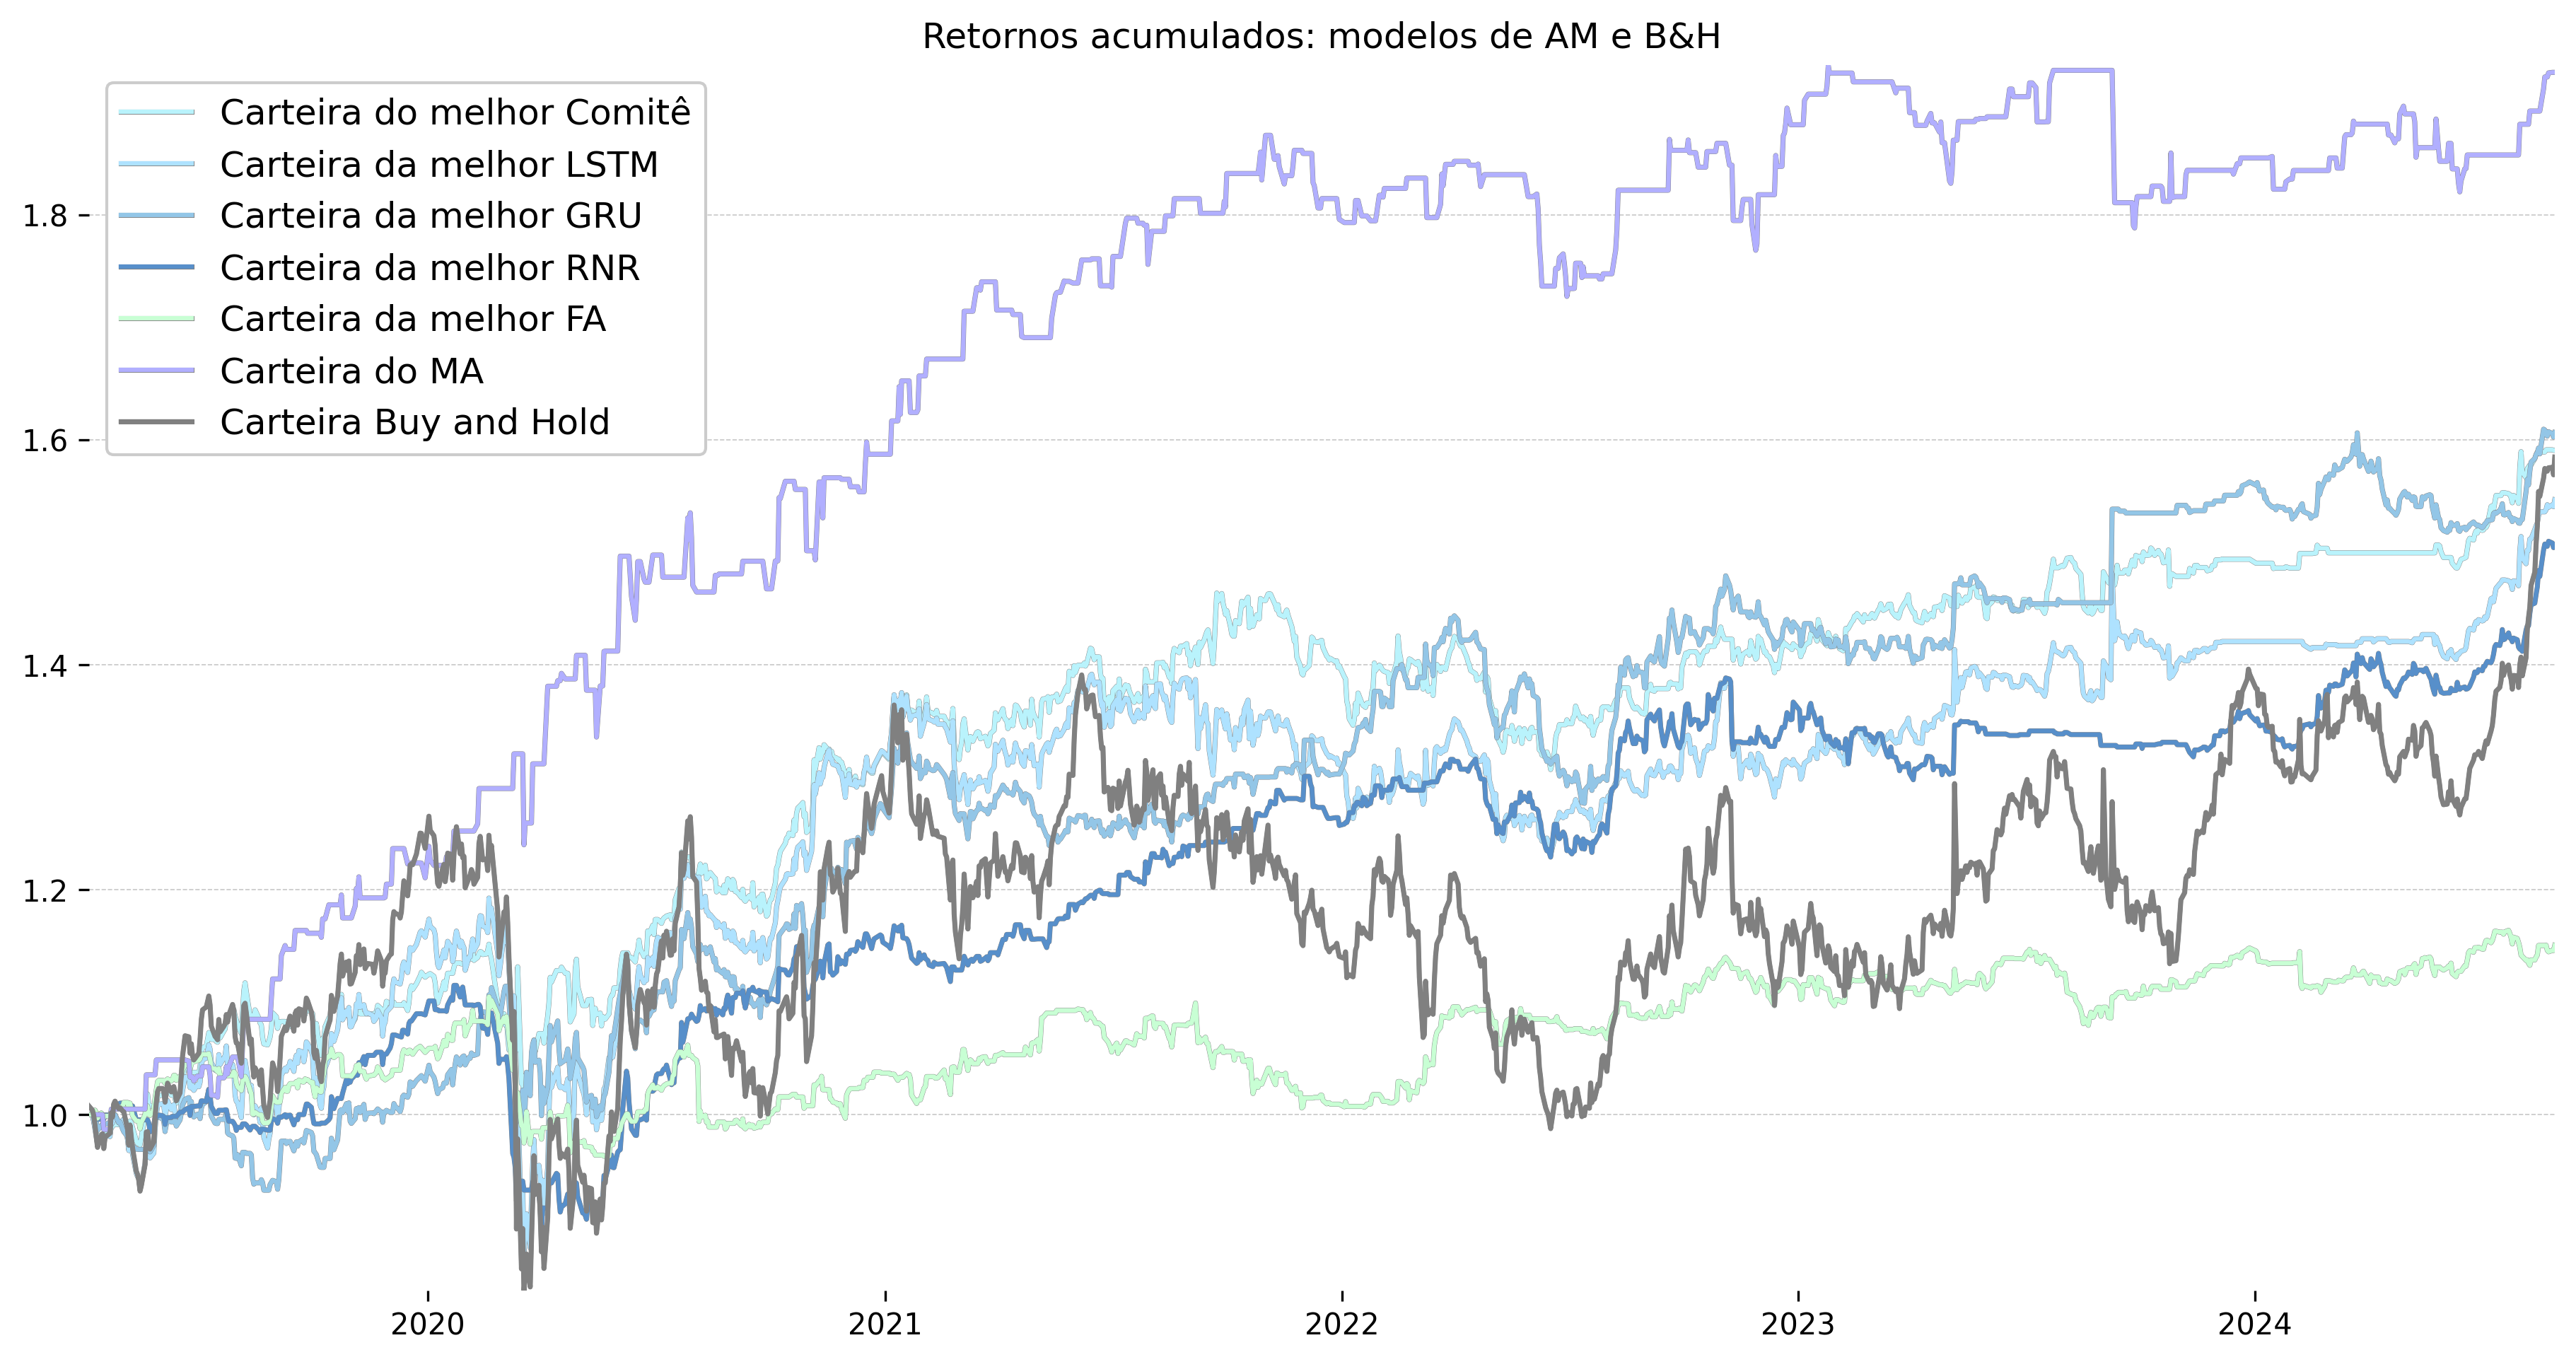

In [34]:
plot_many_returns_series(
    [cuml_perf_ensemble, cuml_perf_lstm_01, cuml_perf_gru_1, cuml_perf_rnn_1, cuml_perf_rf_1, cuml_perf_rg_1, buy_and_hold_cuml_returns], 
    ["Carteira do melhor Comitê", "Carteira da melhor LSTM", "Carteira da melhor GRU", "Carteira da melhor RNR", "Carteira da melhor FA", "Carteira do MA", "Carteira Buy and Hold"], 
    daily_returns.index, 
    colors=[model_colors["Comitê"], model_colors["LSTM"], model_colors["GRU"], model_colors["RNR"], model_colors["FA"], model_colors["MA"], model_colors["B&H"]],
    title="Retornos acumulados: modelos de AM e B&H"
)

In [36]:
buy_and_hold_cuml_returns

,Cumulative Return
Date,
2019-04-05,1.007758
2019-04-08,1.003764
2019-04-09,0.998745
2019-04-10,0.990433
2019-04-11,0.980283
...,...
2024-08-22,1.572064
2024-08-23,1.575020
2024-08-26,1.575424


In [37]:
bh_final_cuml = np.float64(buy_and_hold_cuml_returns.iloc[-1])
bh_final_cuml

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_40398/2071188292.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  bh_final_cuml = np.float64(buy_and_hold_cuml_returns.iloc[-1])


1.5845857328102673

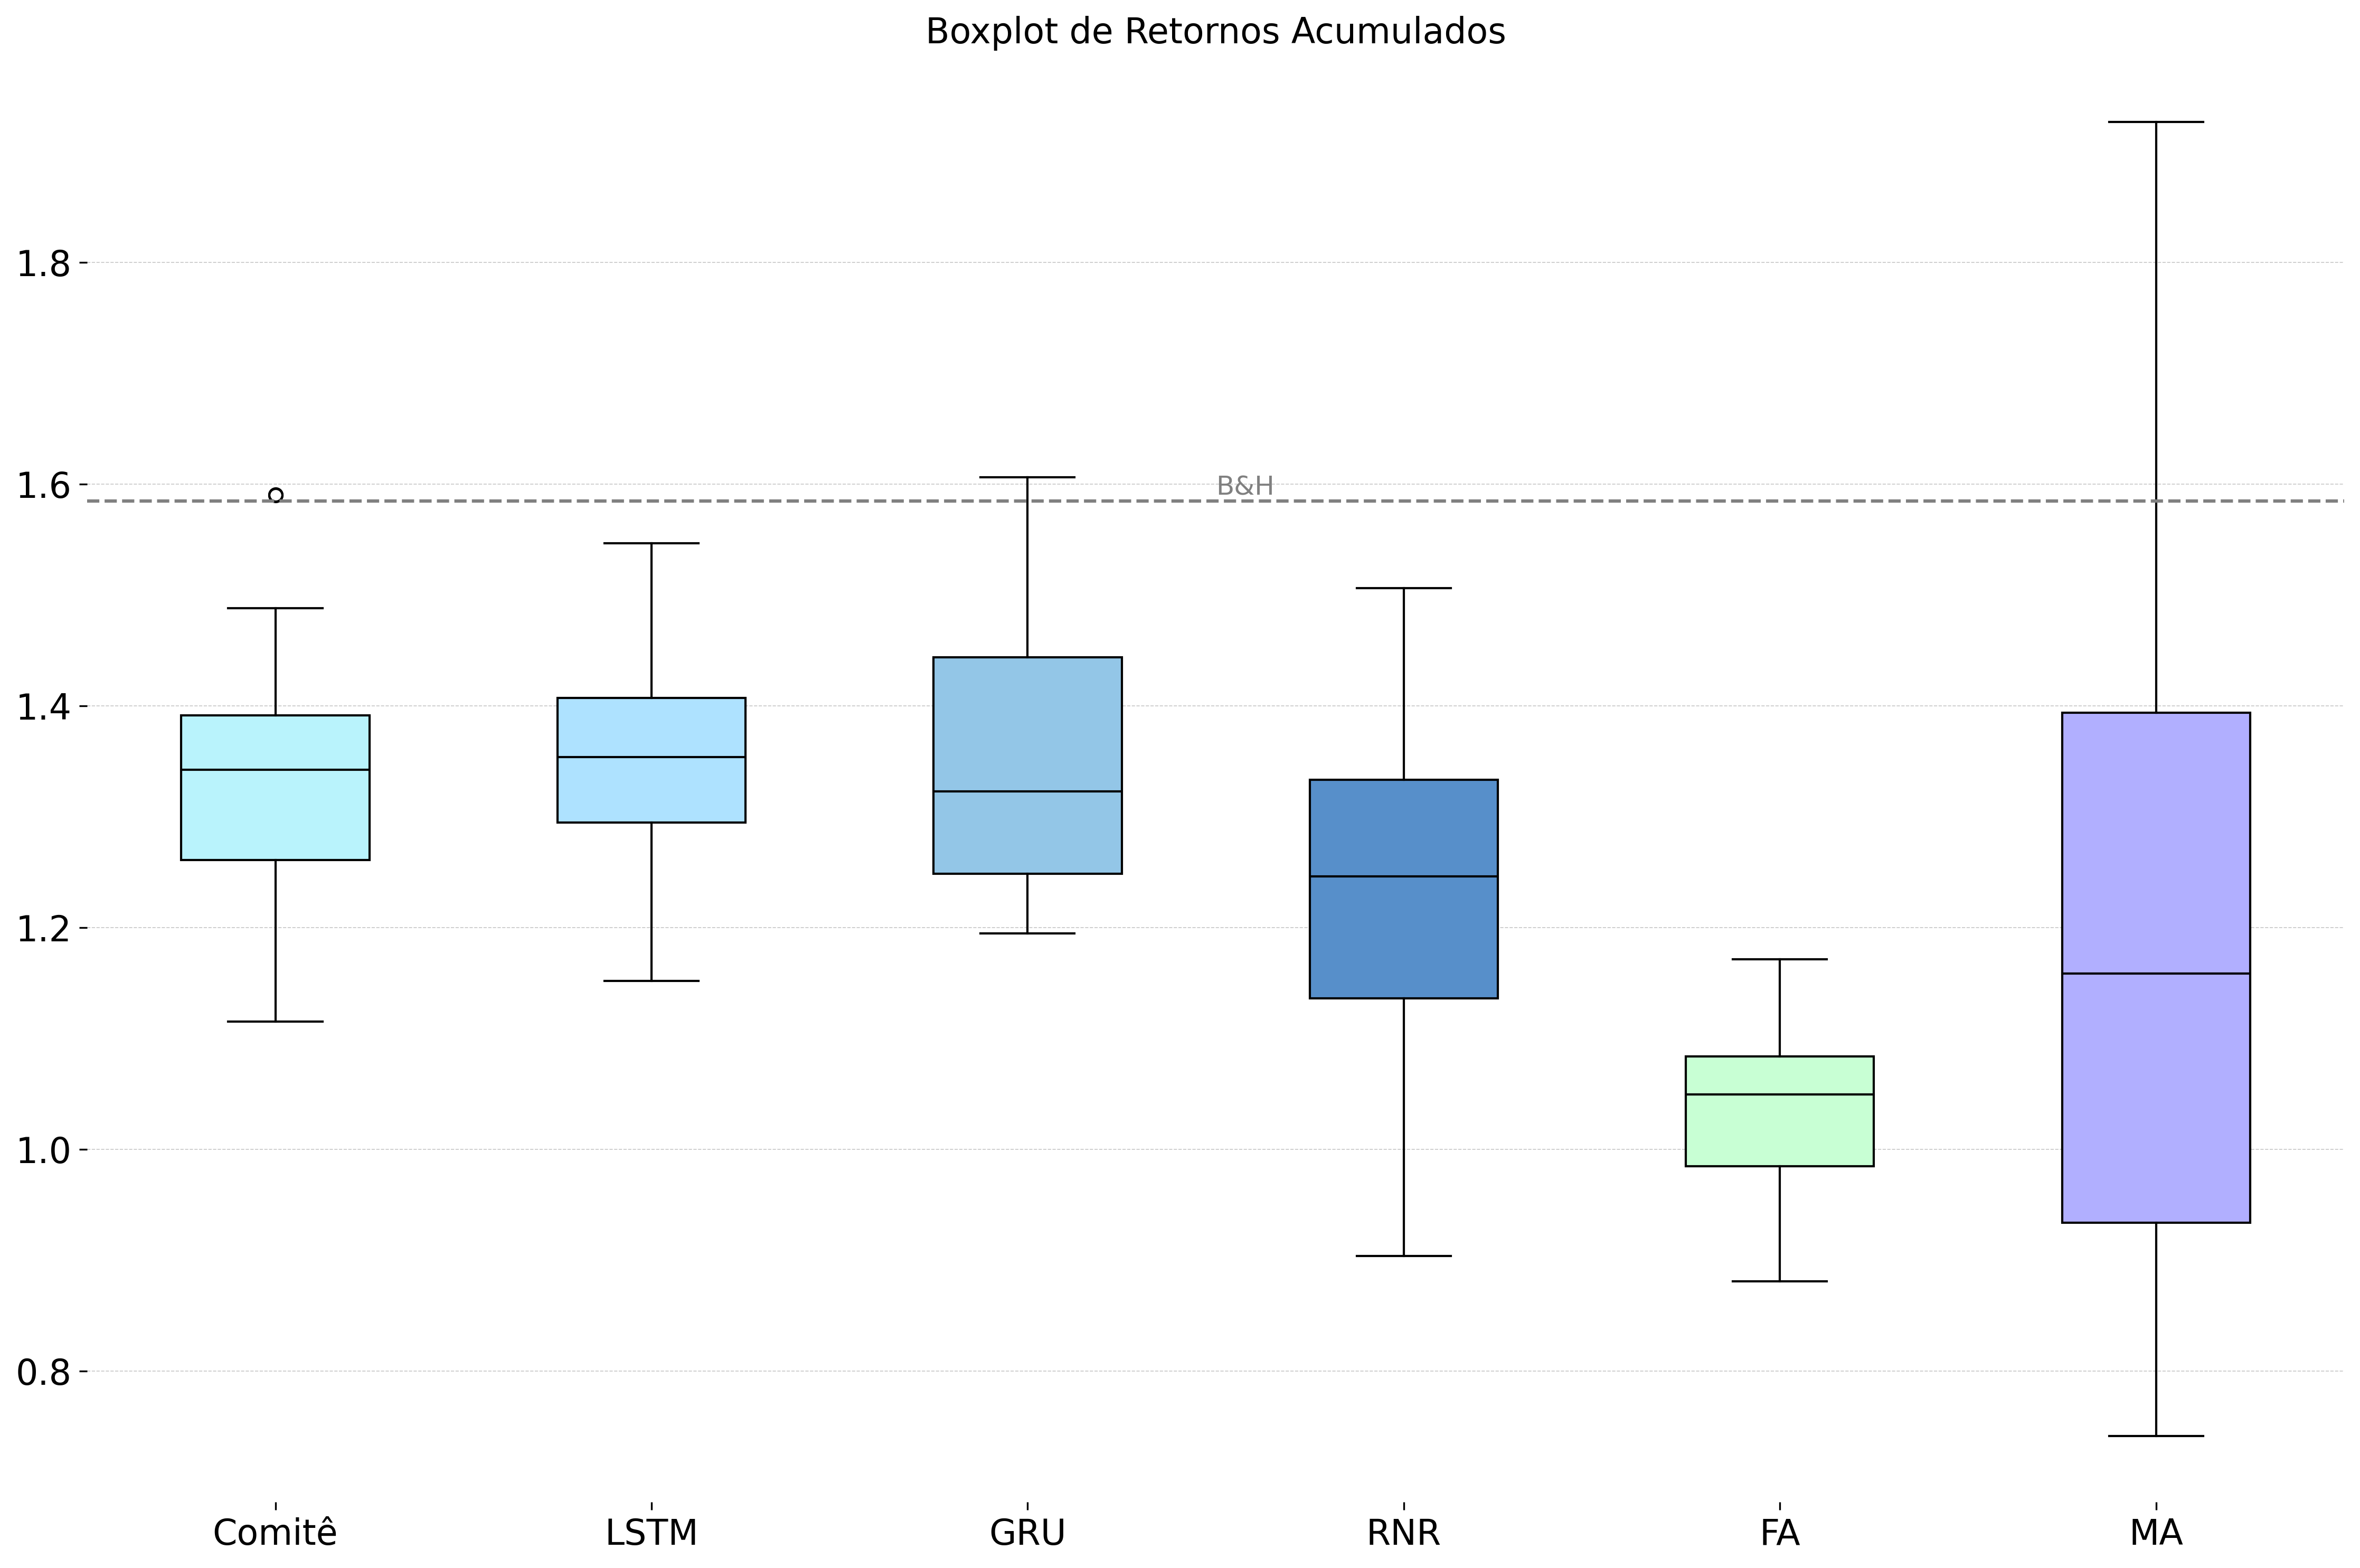

In [38]:
plot_distribution_and_stddev([
    ensemble_cuml_returns_dist,
    lstm_cuml_returns_dist,
    gru_cuml_returns_dist,
    rnn_cuml_returns_dist,
    rf_cuml_returns_dist,
    rg_cuml_returns_dist
],
    "Retornos Acumulados",
    models=list_of_models,
    legend_size=16,
    benchmark_color="grey",
    benchmark_name="B&H",
    benchmark_value=bh_final_cuml
)

In [39]:
print_statistics_table_for_series([
    ensemble_cuml_returns_dist,
    lstm_cuml_returns_dist,
    gru_cuml_returns_dist,
    rnn_cuml_returns_dist,
    rf_cuml_returns_dist,
    rg_cuml_returns_dist
], models=list_of_models)

+--------+--------+---------+--------+--------+---------------+--------+
| modelo | média  | mediana |  max   |  min   | desvio padrão | range  |
+--------+--------+---------+--------+--------+---------------+--------+
| Comitê | 1.3380 |  1.3423 | 1.5905 | 1.1151 |     0.1081    | 0.4754 |
|  LSTM  | 1.3472 |  1.3536 | 1.5467 | 1.1518 |     0.0910    | 0.3949 |
|  GRU   | 1.3543 |  1.3230 | 1.6064 | 1.1945 |     0.1126    | 0.4119 |
|  RNR   | 1.2326 |  1.2461 | 1.5061 | 0.9038 |     0.1418    | 0.6023 |
|   FA   | 1.0352 |  1.0493 | 1.1713 | 0.8806 |     0.0746    | 0.2907 |
|   MA   | 1.1825 |  1.1583 | 1.9266 | 0.7411 |     0.2961    | 1.1855 |
+--------+--------+---------+--------+--------+---------------+--------+


In [40]:
list_of_cuml_returns = [
    ensemble_cuml_returns_dist,
    lstm_cuml_returns_dist,
    gru_cuml_returns_dist,
    rnn_cuml_returns_dist,
    rf_cuml_returns_dist,
    rg_cuml_returns_dist
]

Shapiro-Wilk Statistic: 0.9677303128051014
P-Value: 0.4790871644288218
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9889826306153976
P-Value: 0.984982741345133
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9283967833216404
P-Value: 0.04452438928484323
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal


Shapiro-Wilk Statistic: 0.9852784387059565
P-Value: 0.941830639891692
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.973639598635923
P-Value: 0.6427361973889354
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9612326558832103
P-Value: 0.3329554867742086
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution




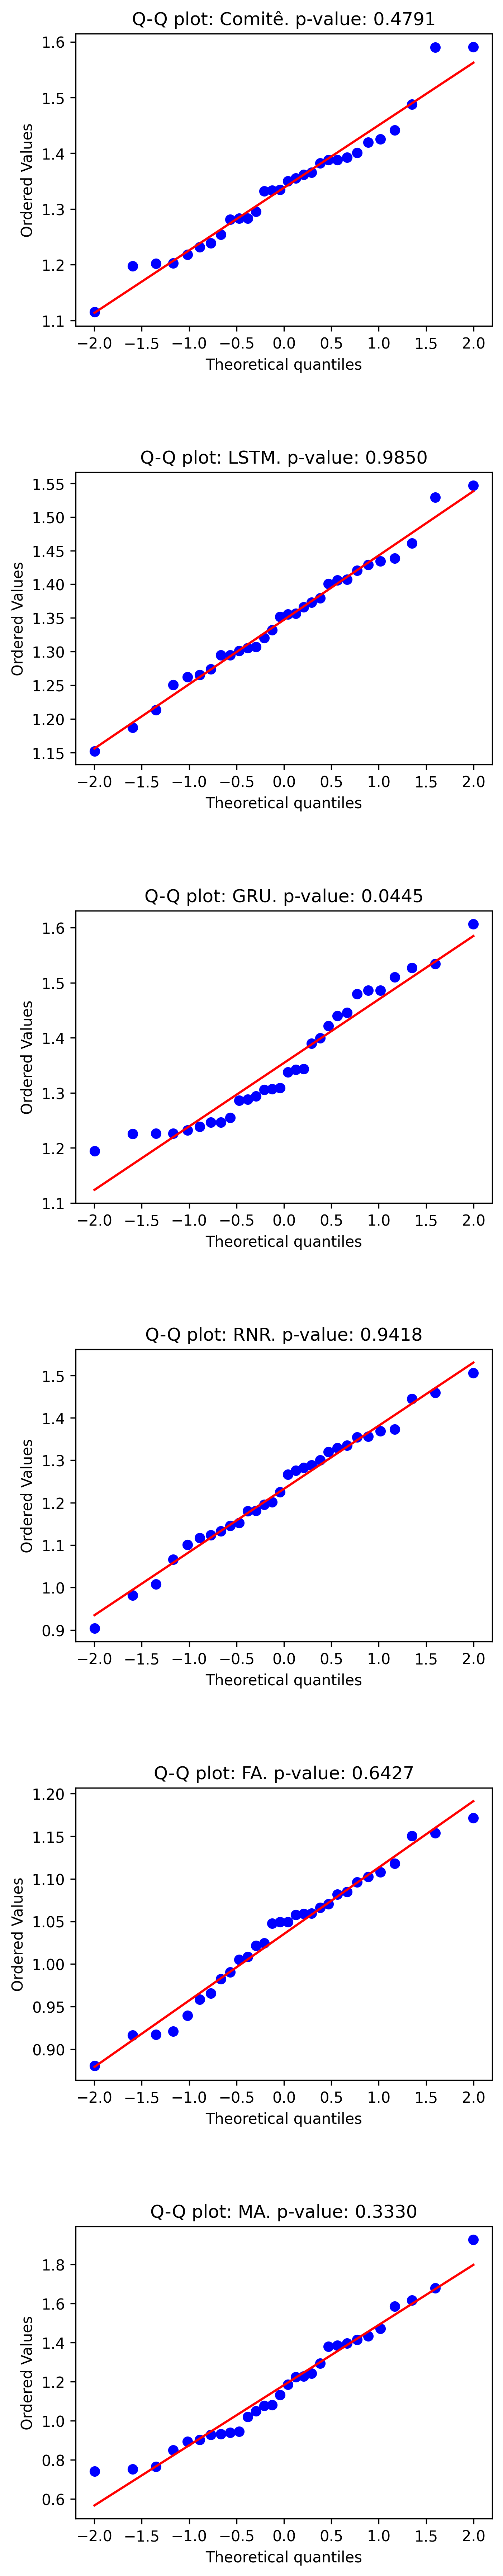

In [41]:
subplot_size = 5 

num_dists = len(list_of_cuml_returns)
fig_height = subplot_size * num_dists
fig_width = subplot_size

plt.figure(figsize=(fig_width, fig_height))

for i, dist in enumerate(list_of_cuml_returns):

    _, p_value = shapiro_wilk_gaussian_test(dist)
    print("")
    print("")

    mean = np.array(dist).mean()
    std = np.array(dist).std()

    plt.subplot(len(list_of_cuml_returns), 1, i+1)
    plt.axis(True)
    probplot(dist, dist="norm", plot=plt)
    # plt.title(f"{list_of_models[i]}; Mean: {mean:.6f}; Stddev: {std:.6f}")
    plt.title(f"Q-Q plot: {list_of_models[i]}. p-value: {p_value:.4f}")
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

Comitê
W statistic: 355.0
p-value: 0.005299130454659462
Reject H0: the evidence shows that the two groups differ in means for alternative greater
LSTM
W statistic: 351.0
p-value: 0.006831620819866657
Reject H0: the evidence shows that the two groups differ in means for alternative greater
GRU
W statistic: 356.0
p-value: 0.00496575515717268
Reject H0: the evidence shows that the two groups differ in means for alternative greater
RNR
W statistic: 281.0
p-value: 0.1642349287867546
Do not reject H0: there is not enough evidence to support the alternative that the first group's mean is greater than the second
FA
W statistic: 139.0
p-value: 0.9738683262839913
Do not reject H0: there is not enough evidence to support the alternative that the first group's mean is greater than the second


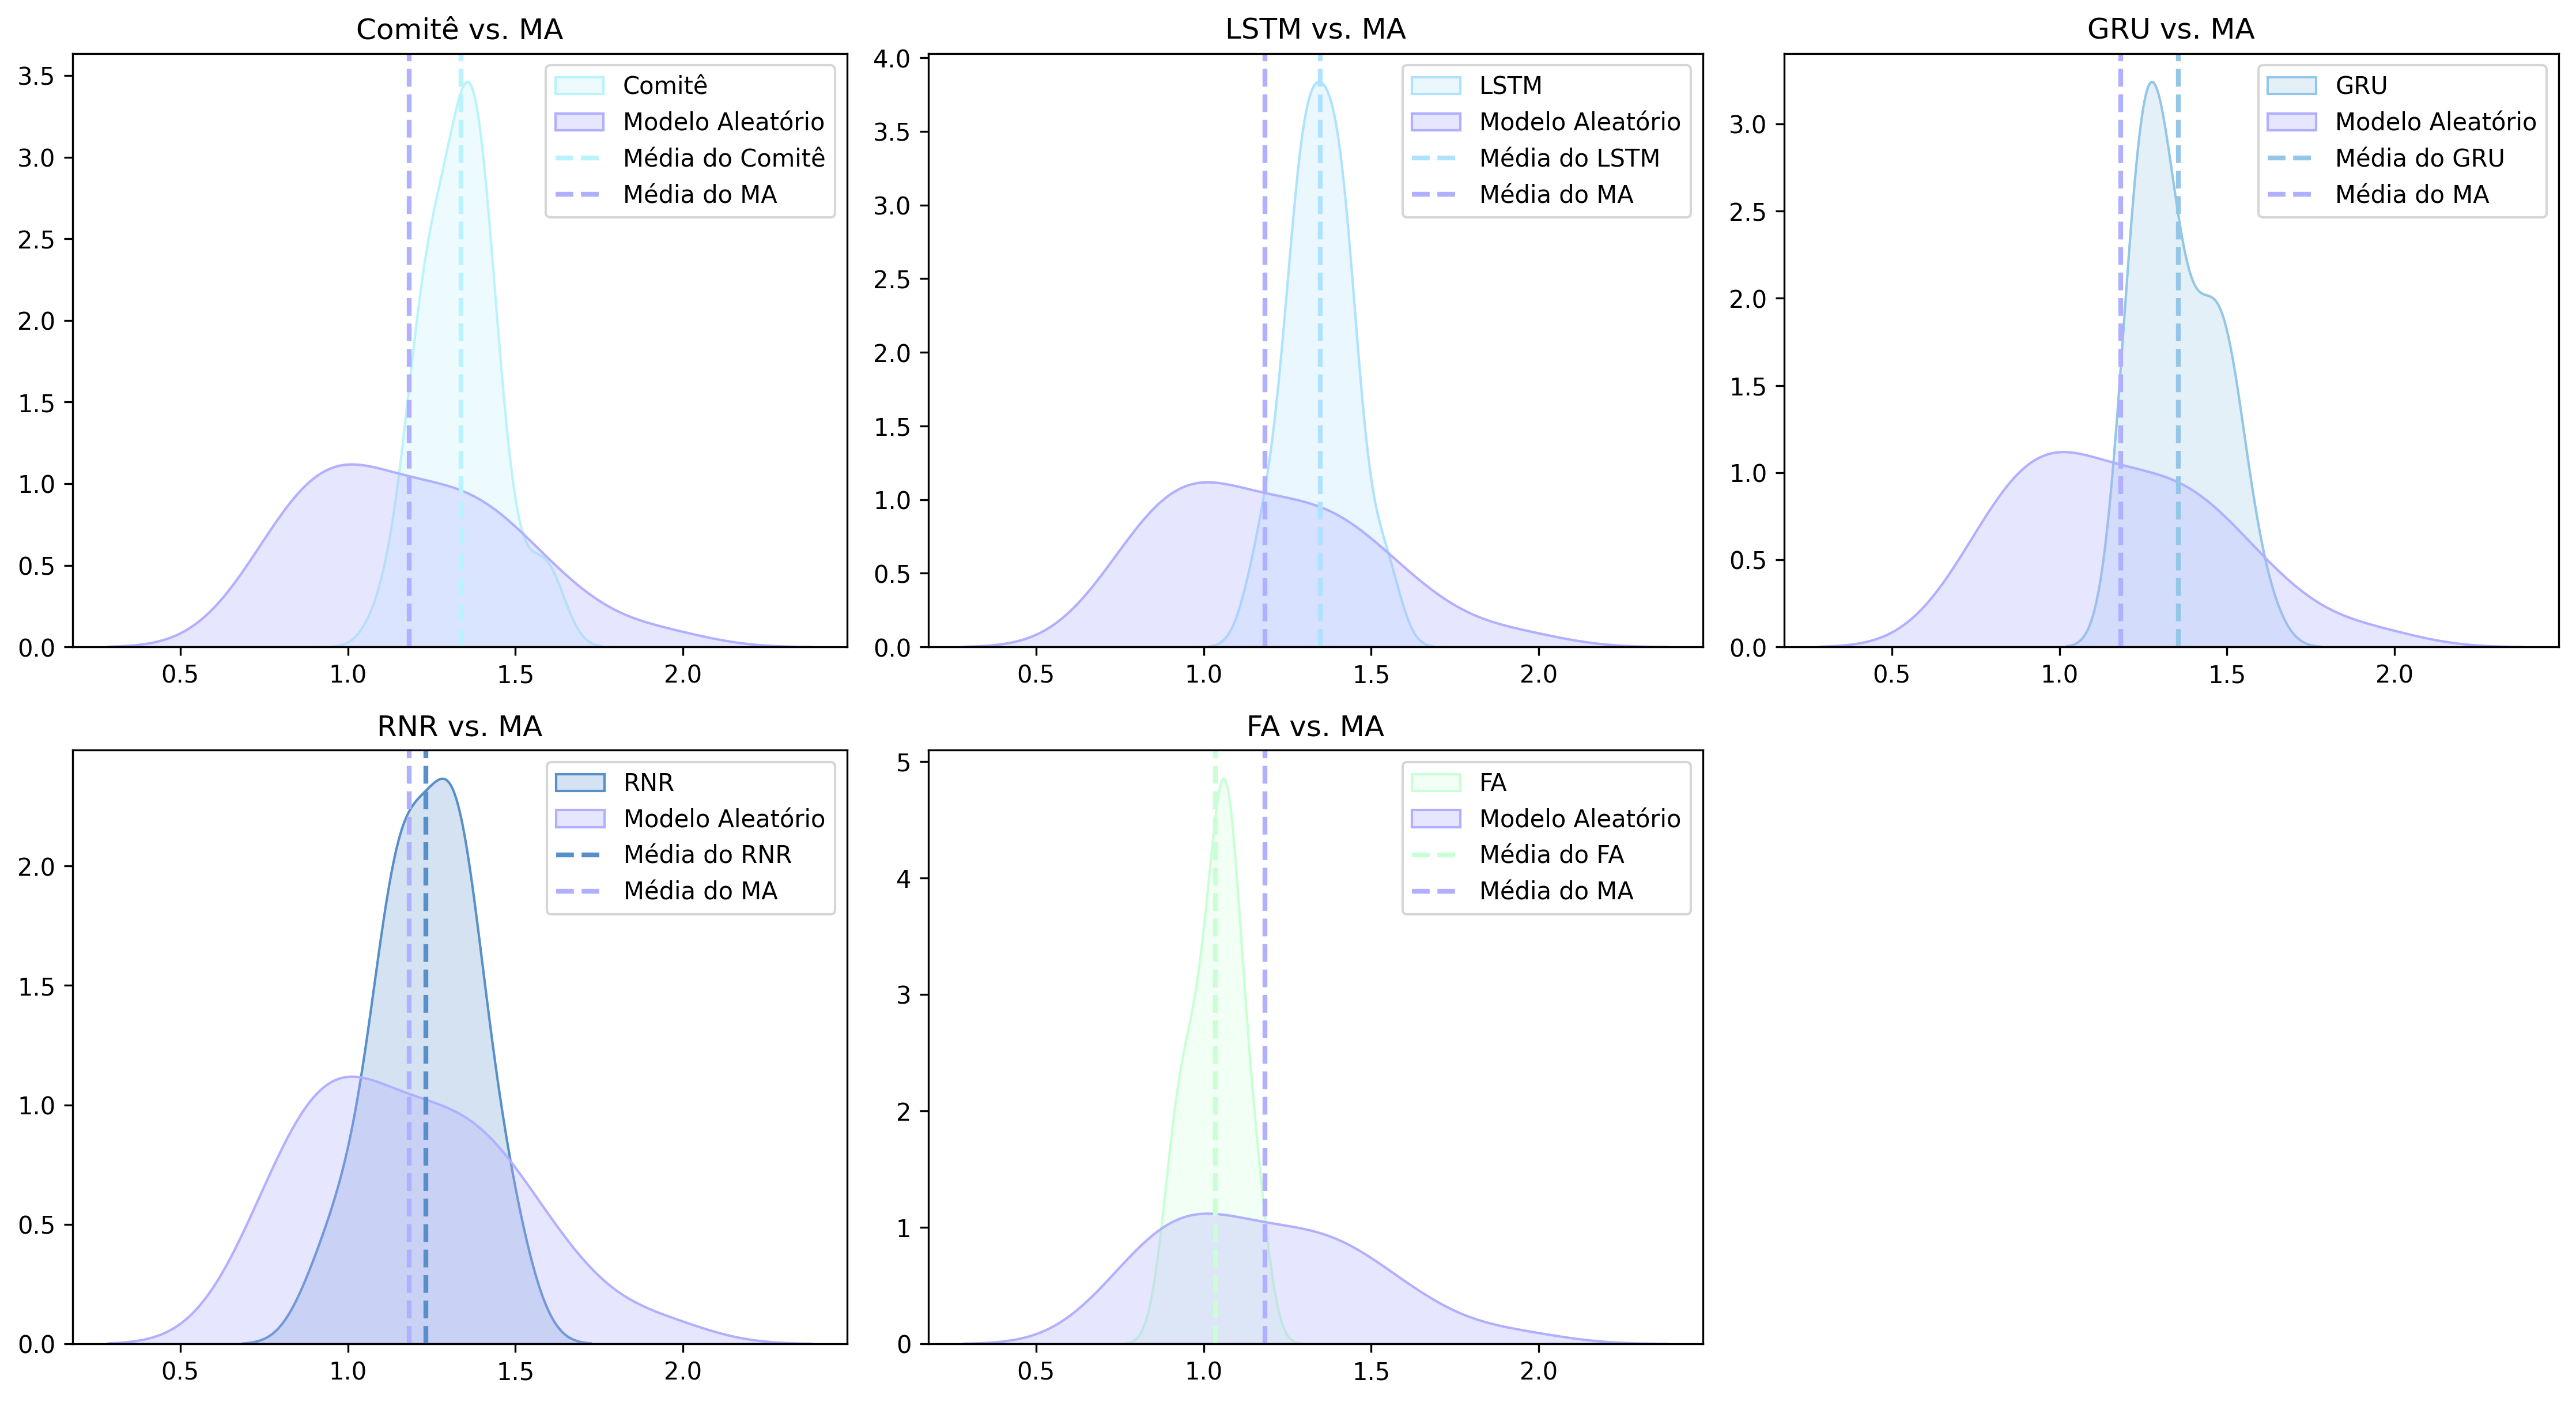

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # Transforma a matriz de eixos em uma lista para fácil indexação

for i, (dist, model) in enumerate(zip(list_of_cuml_returns[:-1], list_of_models)):
    if i >= 5:
        break  # Garante que apenas 5 gráficos sejam plotados

    print(model)
    wilcoxon_signed_rank(dist, rg_cuml_returns_dist, "greater")
    
    mean1_value = np.mean(dist)
    mean2_value = np.mean(rg_cuml_returns_dist)

    ax = axes[i]
    sns.kdeplot(dist, label=f"{model}", color=model_colors[model], fill=True, ax=ax)
    sns.kdeplot(rg_cuml_returns_dist, label="Modelo Aleatório", color=model_colors["MA"], fill=True, alpha=0.3, ax=ax)
    
    ax.axvline(mean1_value, color=model_colors[model], linestyle="dashed", linewidth=2, label=f"Média do {model}", alpha=1)
    ax.axvline(mean2_value, color=model_colors["MA"], linestyle="dashed", linewidth=2, label="Média do MA", alpha=1)
    
    ax.set_title(f"{model} vs. MA")
    ax.set_ylabel("")
    ax.legend()

# Remove eixos vazios caso sobrem
for j in range(i + 1, 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [43]:
list_of_cuml_returns[0]

[1.387759261860655,
 1.2389508085027803,
 1.4253900554585934,
 1.3345986753303547,
 1.4412632815987392,
 1.3500999892992978,
 1.2828222354428485,
 1.4879635919991971,
 1.2543482341668526,
 1.3877370166947862,
 1.419637482059258,
 1.2828549097311146,
 1.5905318676720641,
 1.3320086150854193,
 1.2316428093883136,
 1.115097840840469,
 1.3656012142344987,
 1.3618393930585286,
 1.3823034372690197,
 1.2951012524763545,
 1.3334500884397351,
 1.3925014140524472,
 1.5900669129148237,
 1.2018256056274508,
 1.4006771931986022,
 1.2024599636898399,
 1.1973194325819154,
 1.2811924146308369,
 1.2178385890231254,
 1.3554202402283682]

In [44]:
list_of_models

['Comitê', 'LSTM', 'GRU', 'RNR', 'FA', 'MA']

Comitê
W statistic: 3.0
p-value: 4.6566128730773926e-09
Reject H0: the evidence shows that the two groups differ in means for alternative less
LSTM
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the two groups differ in means for alternative less
GRU
W statistic: 1.0
p-value: 1.862645149230957e-09
Reject H0: the evidence shows that the two groups differ in means for alternative less
RNR
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the two groups differ in means for alternative less
FA
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the two groups differ in means for alternative less
MA
W statistic: 17.0
p-value: 1.9278377294540405e-07
Reject H0: the evidence shows that the two groups differ in means for alternative less


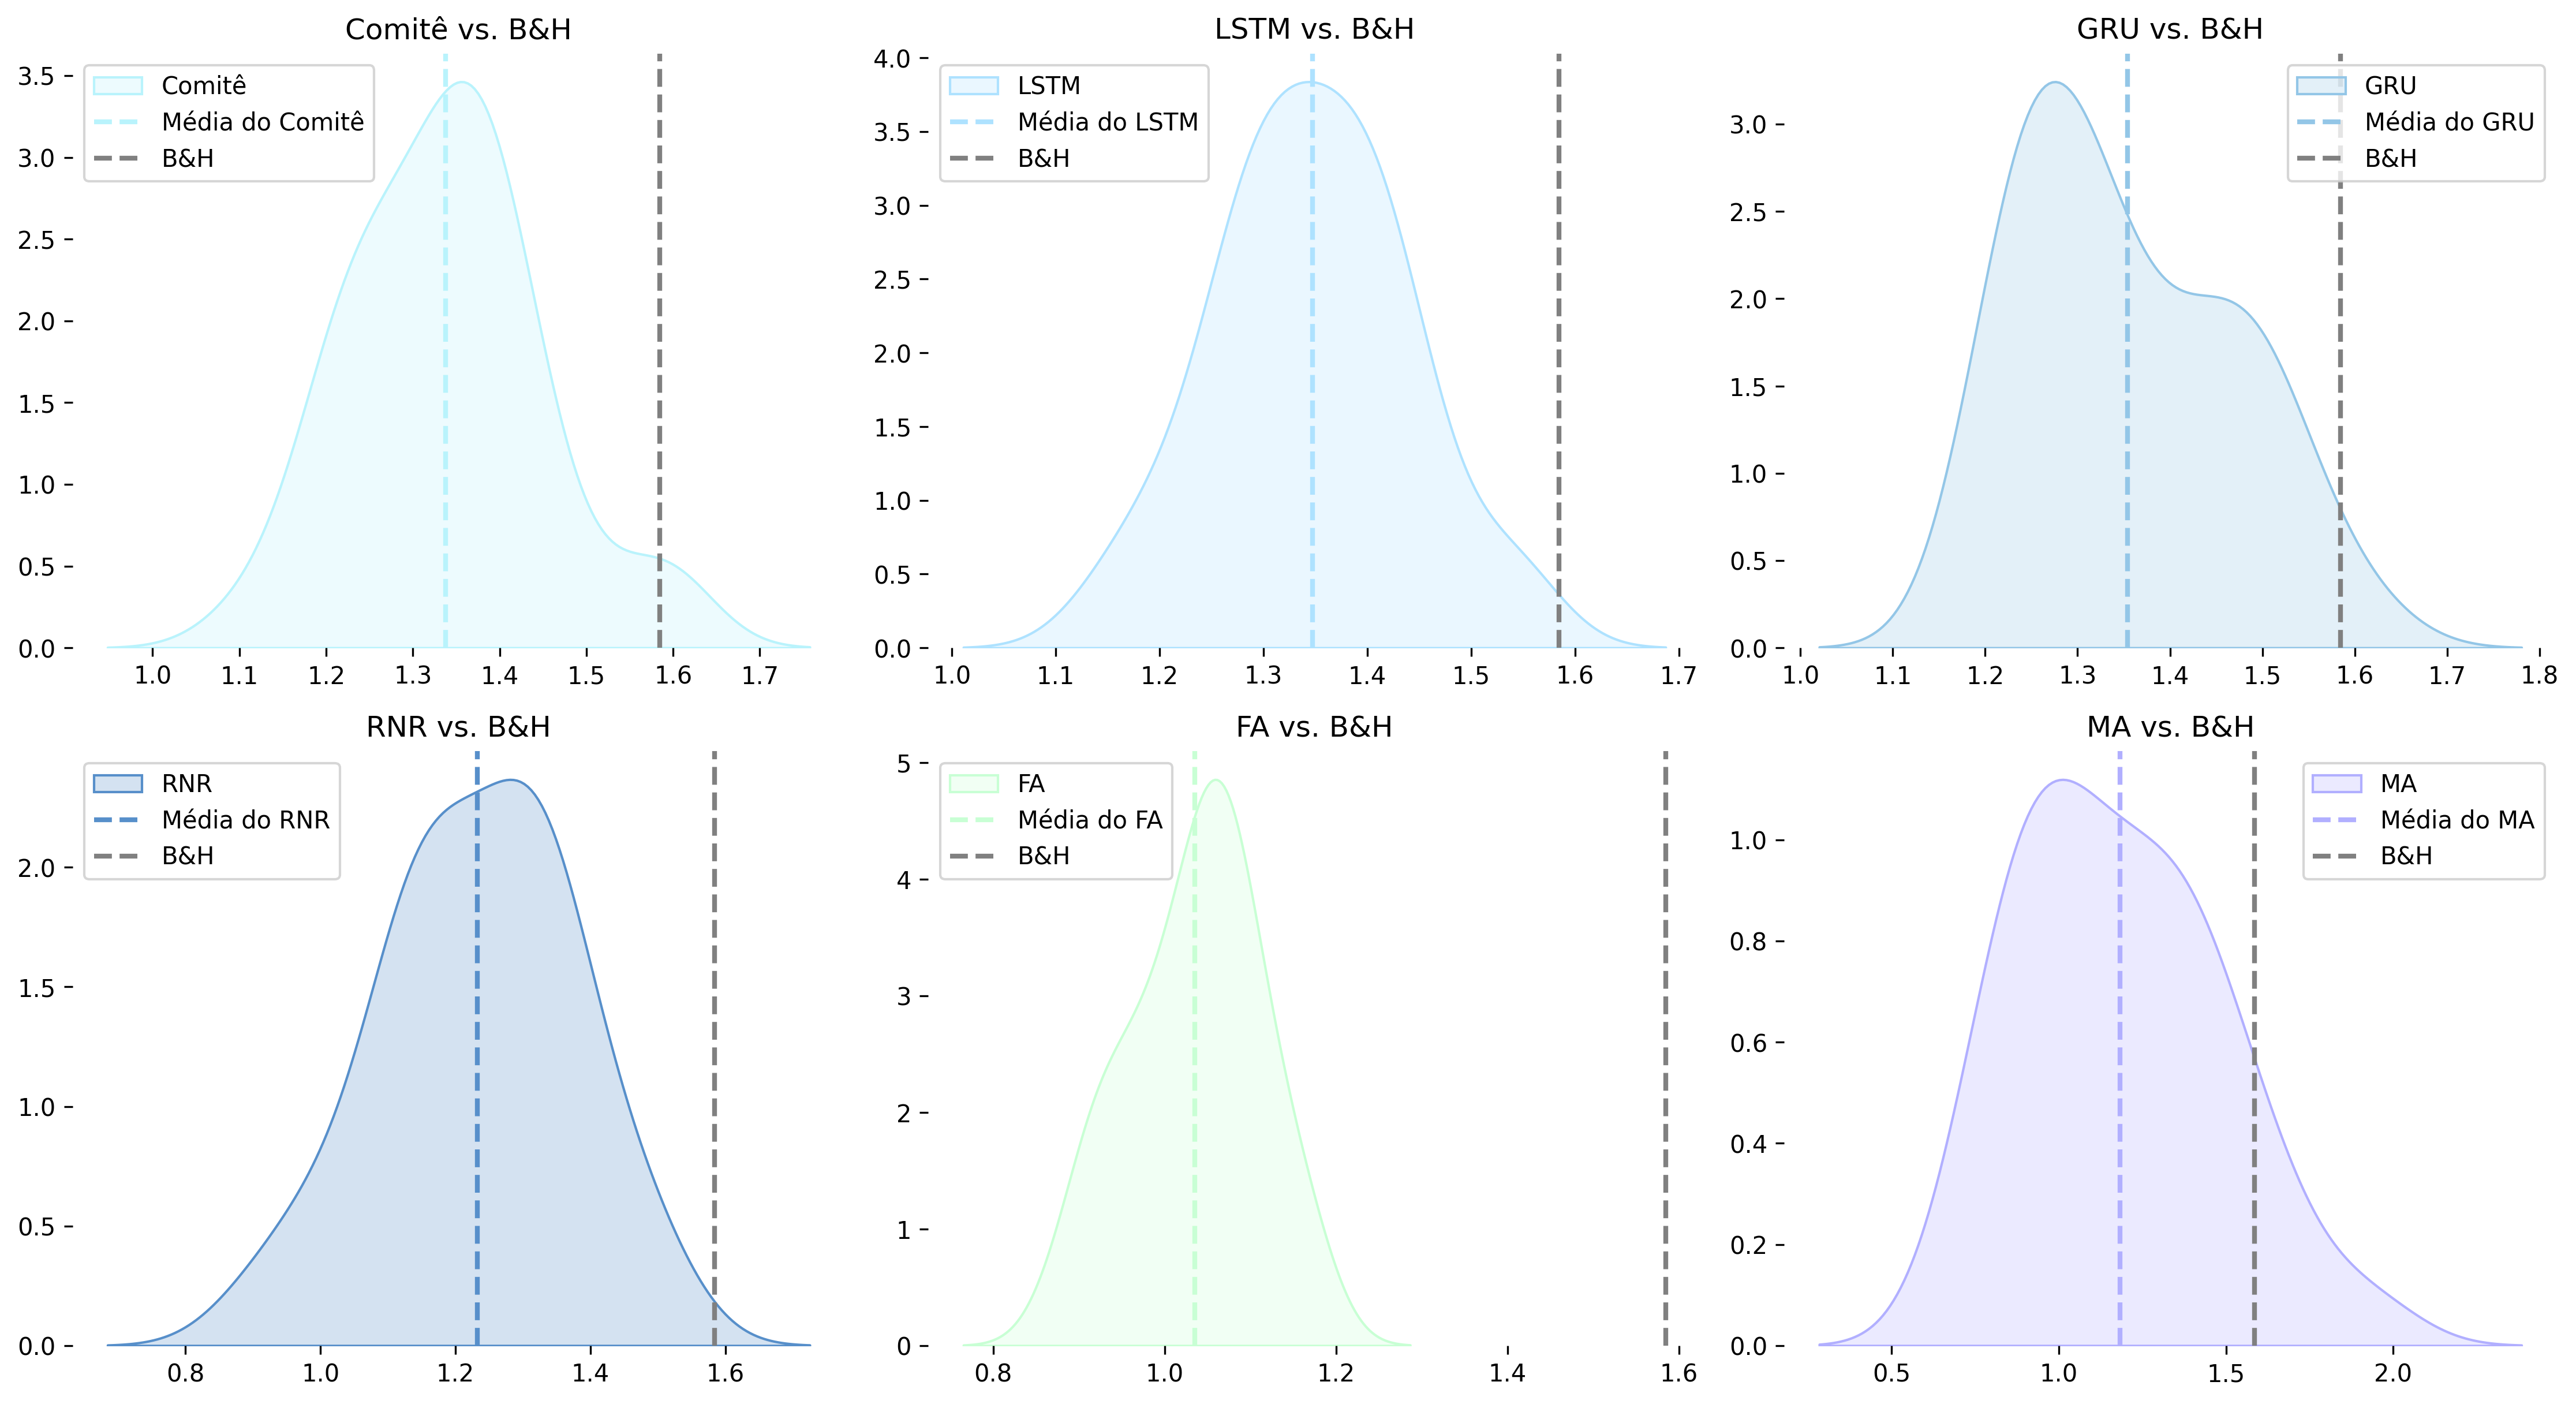

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # Transforma a matriz de eixos em uma lista para fácil indexação

for i, (dist, model) in enumerate(zip(list_of_cuml_returns, list_of_models)):
    if i >= 6:
        break  # Garante que apenas 5 gráficos sejam plotados

    print(model)
    wilcoxon_signed_rank(dist, bh_final_cuml, "less")
    
    mean1_value = np.mean(dist)

    ax = axes[i]
    for spine in ax.spines.values():
        spine.set_visible(False)
    sns.kdeplot(dist, label=f"{model}", color=model_colors[model], fill=True, ax=ax)
    # sns.kdeplot(rg_cuml_returns_dist, label="Modelo Aleatório", color=model_colors["MA"], fill=True, alpha=0.3, ax=ax)
    
    ax.axvline(mean1_value, color=model_colors[model], linestyle="dashed", linewidth=2, label=f"Média do {model}", alpha=1)
    ax.axvline(bh_final_cuml, color=model_colors["B&H"], linestyle="dashed", linewidth=2, label="B&H", alpha=1)
    
    ax.set_title(f"{model} vs. B&H")
    ax.set_ylabel("")
    ax.legend()

# Remove eixos vazios caso sobrem
for j in range(i + 1, 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()